# 四信号合并与综合分析

本 Notebook 是本目录的主要运行文件。它读取两个最新本地五列结果和完整现货快照，先核对日期与基础三状态，再生成 9 列合并文件、四个信号的事件日/前向/持仓段审计、价格路径图和 5 份中文 Markdown 报告。

现行口径：四个信号都只作用于对应的一天；退出信号只把匹配的 `-1/+1` 当天改成 0，零段入口只把基础 0 的当天改成 `-1/+1`，后续日期不延续重标。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'analysis_pipeline.py').exists() and (ROOT / '02_HTML生成工具' / 'analysis_pipeline.py').exists():
    ROOT = ROOT / '02_HTML生成工具'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis_pipeline import run_all

results = run_all()
print('分析根目录:', ROOT)
print('合并文件:', results['manifest']['combined_file'])
print('行数:', len(results['combined']))
print('日期:', results['combined']['date'].min(), '->', results['combined']['date'].max())

分析根目录: /Users/hzy/Desktop/0817合并查看
合并文件: /Users/hzy/Desktop/0817合并查看/01_报告资料与基础上传包/数据源/combined_four_signals_nine_columns.csv
行数: 2091
日期: 2018-01-03 00:00:00 -> 2026-08-17 00:00:00


## 1. 合并文件与一致性审计

In [2]:
display(pd.DataFrame([results['merge_audit']]))
display(results['combined'].head(8))
display(results['combined'].tail(8))
print('基础状态计数:', results['combined']['three_state'].value_counts().sort_index().to_dict())
print('退出组最终计数:', results['combined']['reversal_final_three_state'].value_counts().sort_index().to_dict())
print('转移组最终计数:', results['combined']['transfer_final_three_state'].value_counts().sort_index().to_dict())
print('四信号最终计数:', results['combined']['combined_final_three_state'].value_counts().sort_index().to_dict())
print('价格行:', results['price_audit'])

,reversal_source,transfer_source,reversal_rows,transfer_rows,date_match,base_three_state_match,reversal_date_min,reversal_date_max,transfer_date_min,transfer_date_max,reversal_base_counts,transfer_base_counts,reversal_signal_counts,transfer_signal_counts,combined_rows,combined_columns,reversal_final_reproduction_match,transfer_final_reproduction_match,combined_final_counts,entry_conflict_days
0,/Users/hzy/Desktop/0817合并查看/01_报告资料与基础上传包/数据源/1545_...,/Users/hzy/Desktop/0817合并查看/01_报告资料与基础上传包/数据源/长0_ev...,2091,2091,True,True,2018-01-03,2026-08-17,2018-01-03,2026-08-17,"{-1: 233, 0: 1452, 1: 406}","{-1: 233, 0: 1452, 1: 406}","{'minus_exit_signal': 45, 'plus_exit_signal': 62}","{'minus_entry_signal': 136, 'plus_entry_signal...",2091,"[date, three_state, minus_exit_signal, plus_ex...",True,True,"{-1: 321, 0: 1343, 1: 427}",3


,date,three_state,minus_exit_signal,plus_exit_signal,reversal_final_three_state,minus_entry_signal,plus_entry_signal,transfer_final_three_state,combined_final_three_state
0,2018-01-03,0,0,0,0,0,0,0,0
1,2018-01-04,0,0,0,0,0,0,0,0
2,2018-01-05,0,0,0,0,0,0,0,0
3,2018-01-08,0,0,0,0,0,0,0,0
4,2018-01-09,0,0,0,0,0,0,0,0
5,2018-01-10,0,0,0,0,0,0,0,0
6,2018-01-11,0,0,0,0,0,0,0,0
7,2018-01-12,0,0,0,0,0,0,0,0


,date,three_state,minus_exit_signal,plus_exit_signal,reversal_final_three_state,minus_entry_signal,plus_entry_signal,transfer_final_three_state,combined_final_three_state
2083,2026-08-06,0,0,0,0,0,0,0,0
2084,2026-08-07,0,0,0,0,0,0,0,0
2085,2026-08-10,0,0,0,0,0,0,0,0
2086,2026-08-11,0,0,0,0,1,0,-1,-1
2087,2026-08-12,0,0,0,0,0,0,0,0
2088,2026-08-13,0,0,0,0,0,0,0,0
2089,2026-08-14,0,0,0,0,0,0,0,0
2090,2026-08-17,0,0,0,0,0,0,0,0


基础状态计数: {-1: 233, 0: 1452, 1: 406}
退出组最终计数: {-1: 188, 0: 1559, 1: 344}
转移组最终计数: {-1: 366, 0: 1236, 1: 489}
四信号最终计数: {-1: 321, 0: 1343, 1: 427}
价格行: {'price_source': '/Users/hzy/Desktop/0817合并查看/01_报告资料与基础上传包/数据源/long0_spot_rq_20260817.parquet', 'price_rows': 5250, 'price_date_min': Timestamp('2005-01-04 00:00:00'), 'price_date_max': Timestamp('2026-08-14 00:00:00'), 'overlap_with_reversal_price_rows': 2756, 'overlap_ohlc_exact_within_1e-7': True}


## 2. 四个信号逐个有效性

In [3]:
event_cols = ['signal_label', 'model', 'event_days', 'eligible_base_days', 'coverage_pct', 'realized_event_days', 'directional_mean_bp', 'mean_ci_low_bp', 'mean_ci_high_bp', 'eligible_directional_mean_bp', 'signal_lift_vs_eligible_bp', 'directional_win_rate_pct']
display(results['event_summary'][event_cols].round(2))
print('分阶段效果：')
display(results['event_phase_summary'].round(2))

,signal_label,model,event_days,eligible_base_days,coverage_pct,realized_event_days,directional_mean_bp,mean_ci_low_bp,mean_ci_high_bp,eligible_directional_mean_bp,signal_lift_vs_eligible_bp,directional_win_rate_pct
0,负向退出（-1→0）,V55 / inductive conformal martingale,45,233,19.31,45,57.35,-0.98,120.92,-20.18,77.53,62.22
1,正向退出（+1→0）,V80 / catch22 dynamics classifier,62,406,15.27,62,46.97,6.16,86.50,-23.83,70.80,51.61
2,零段向下（0→-1）,V38 / volume breakout,136,1452,9.37,136,27.43,3.09,52.64,0.18,27.24,55.88
3,零段向上（0→+1）,V57 / recurrence quantification,86,1452,5.92,86,18.80,-13.30,52.57,-0.18,18.99,52.33


分阶段效果：


,signal_key,signal_label,phase,event_days,realized_event_days,eligible_base_days,coverage_pct,directional_mean_bp,directional_median_bp,directional_win_rate_pct,eligible_directional_mean_bp,lift_vs_eligible_bp,eligible_directional_win_rate_pct
0,minus_exit,负向退出（-1→0）,Full,45,45,233,19.31,57.35,19.98,62.22,-20.18,77.53,48.93
1,minus_exit,负向退出（-1→0）,Development,26,26,134,19.40,40.55,27.58,65.38,-23.76,64.31,50.00
2,minus_exit,负向退出（-1→0）,Validation,11,11,63,17.46,98.46,-1.50,45.45,-14.53,112.99,44.44
3,minus_exit,负向退出（-1→0）,Test,8,8,36,22.22,55.41,28.62,75.00,-16.75,72.16,52.78
4,plus_exit,正向退出（+1→0）,Full,62,62,406,15.27,46.97,25.64,51.61,-23.83,70.80,42.36
5,plus_exit,正向退出（+1→0）,Development,19,19,204,9.31,53.53,66.60,57.89,-21.53,75.06,40.69
6,plus_exit,正向退出（+1→0）,Validation,10,10,87,11.49,105.53,102.24,60.00,-29.96,135.49,48.28
7,plus_exit,正向退出（+1→0）,Test,33,33,115,28.70,25.45,-4.60,45.45,-23.27,48.72,40.87
8,minus_entry,零段向下（0→-1）,Full,136,136,1452,9.37,27.43,19.09,55.88,0.18,27.24,49.52
9,minus_entry,零段向下（0→-1）,Development,90,90,876,10.27,22.69,19.09,55.56,0.78,21.91,49.20


In [4]:
for key, label in [('minus_exit', '负向退出'), ('plus_exit', '正向退出'), ('minus_entry', '零段向下'), ('plus_entry', '零段向上')]:
    print(f'--- {label} ({key}) ---')
    display(results['event_forward_summary'].query('signal_key == @key').round(2))
    display(results['event_details'].query('signal_key == @key').sort_values('directional_improvement_bp', ascending=False).head(8).round(2))

--- 负向退出 (minus_exit) ---


,signal_key,signal_label,horizon_days,event_n,event_mean_directional_bp,event_median_directional_bp,event_win_rate_pct,event_p25_bp,event_p75_bp,eligible_n,eligible_mean_directional_bp,eligible_win_rate_pct
0,minus_exit,负向退出（-1→0）,1,45,57.35,19.98,62.22,-39.05,126.13,233,-20.18,48.93
1,minus_exit,负向退出（-1→0）,2,45,121.08,48.74,62.22,-60.89,189.71,233,-24.79,45.06
2,minus_exit,负向退出（-1→0）,3,45,128.79,90.68,62.22,-68.13,204.29,233,-23.49,48.07
3,minus_exit,负向退出（-1→0）,5,45,95.46,41.86,55.56,-150.90,245.53,233,-4.95,48.50
4,minus_exit,负向退出（-1→0）,10,44,152.92,134.09,61.36,-85.09,285.86,232,-6.06,45.26


,signal_key,signal_label,date,phase,three_state,base_segment_id,base_segment_length,base_position,signal_position_pct,days_from_segment_start,...,open,close,o2o_h1,o2o_h2,o2o_h3,o2o_h5,o2o_h10,raw_o2o_h1_bp,directional_improvement_bp,price_available
35,minus_exit,负向退出（-1→0）,2024-02-06,Validation,-1,105,5,5,100.00,4,...,4411.30,4805.90,0.09,0.16,0.18,0.16,0.20,912.78,912.78,True
0,minus_exit,负向退出（-1→0）,2018-10-19,Development,-1,9,5,5,100.00,4,...,3958.45,4127.99,0.05,0.10,0.07,0.08,0.10,523.72,523.72,True
17,minus_exit,负向退出（-1→0）,2022-04-27,Development,-1,63,8,7,87.50,6,...,5179.03,5437.04,0.04,0.05,0.08,0.07,0.13,424.55,424.55,True
42,minus_exit,负向退出（-1→0）,2026-07-21,Test,-1,143,7,6,85.71,5,...,7437.45,7800.61,0.04,0.04,0.03,0.02,0.00,409.35,409.35,True
33,minus_exit,负向退出（-1→0）,2024-01-23,Validation,-1,103,7,6,85.71,5,...,4771.50,4865.74,0.02,0.03,0.06,0.03,-0.08,240.40,240.40,True
7,minus_exit,负向退出（-1→0）,2020-03-24,Development,-1,27,8,7,87.50,6,...,5089.15,5096.04,0.02,0.02,0.03,-0.00,0.03,219.34,219.34,True
9,minus_exit,负向退出（-1→0）,2020-09-18,Development,-1,35,6,6,100.00,5,...,6367.79,6469.47,0.02,0.00,0.00,-0.02,0.01,195.41,195.41,True
24,minus_exit,负向退出（-1→0）,2022-12-26,Development,-1,81,9,8,88.89,7,...,5769.07,5843.26,0.02,0.02,0.01,0.02,0.05,153.73,153.73,True


--- 正向退出 (plus_exit) ---


,signal_key,signal_label,horizon_days,event_n,event_mean_directional_bp,event_median_directional_bp,event_win_rate_pct,event_p25_bp,event_p75_bp,eligible_n,eligible_mean_directional_bp,eligible_win_rate_pct
5,plus_exit,正向退出（+1→0）,1,62,46.97,25.64,51.61,-85.92,148.95,406,-23.83,42.36
6,plus_exit,正向退出（+1→0）,2,62,82.13,54.73,59.68,-93.91,198.38,406,-41.44,40.15
7,plus_exit,正向退出（+1→0）,3,62,106.04,87.10,67.74,-49.52,283.65,406,-58.27,39.90
8,plus_exit,正向退出（+1→0）,5,62,104.07,117.81,61.29,-52.32,364.41,406,-74.76,38.18
9,plus_exit,正向退出（+1→0）,10,62,177.54,47.59,59.68,-120.20,453.37,406,-108.78,38.67


...

,signal_key,signal_label,horizon_days,event_n,event_mean_directional_bp,event_median_directional_bp,event_win_rate_pct,event_p25_bp,event_p75_bp,eligible_n,eligible_mean_directional_bp,eligible_win_rate_pct
10,minus_entry,零段向下（0→-1）,1,136,27.43,19.09,55.88,-68.23,98.85,1450,0.18,49.52
11,minus_entry,零段向下（0→-1）,2,136,37.67,24.29,61.03,-82.57,143.93,1449,1.14,49.83
12,minus_entry,零段向下（0→-1）,3,136,48.83,18.90,52.94,-94.66,183.36,1448,2.90,49.65
13,minus_entry,零段向下（0→-1）,5,135,35.05,44.37,54.81,-156.87,200.71,1446,4.24,49.10
14,minus_entry,零段向下（0→-1）,10,135,-2.78,15.10,51.85,-236.66,223.01,1442,0.33,49.86


,signal_key,signal_label,date,phase,three_state,base_segment_id,base_segment_length,base_position,signal_position_pct,days_from_segment_start,...,open,close,o2o_h1,o2o_h2,o2o_h3,o2o_h5,o2o_h10,raw_o2o_h1_bp,directional_improvement_bp,price_available
237,minus_entry,零段向下（0→-1）,2026-03-03,Test,0,132,28,19,67.86,18,...,8651.06,8281.61,-0.06,-0.03,-0.04,-0.04,-0.05,-558.40,558.40,True
224,minus_entry,零段向下（0→-1）,2025-04-03,Test,0,124,64,8,12.50,7,...,5842.62,5845.50,-0.05,-0.10,-0.10,-0.06,-0.05,-545.39,545.39,True
118,minus_entry,零段向下（0→-1）,2018-06-19,Development,0,4,89,62,69.66,61,...,5396.68,5141.71,-0.05,-0.04,-0.06,-0.06,-0.05,-523.70,523.70,True
129,minus_entry,零段向下（0→-1）,2019-04-25,Development,0,18,33,32,96.97,31,...,5652.01,5458.42,-0.04,-0.04,-0.07,-0.13,-0.13,-397.00,397.00,True
111,minus_entry,零段向下（0→-1）,2018-03-22,Development,0,4,89,4,4.49,3,...,6130.05,6101.23,-0.04,-0.07,-0.03,-0.02,-0.02,-353.47,353.47,True
241,minus_entry,零段向下（0→-1）,2026-07-13,Test,0,142,4,4,100.00,3,...,8409.14,8138.14,-0.03,-0.01,-0.05,-0.10,-0.11,-325.95,325.95,True
133,minus_entry,零段向下（0→-1）,2019-07-08,Development,0,20,70,39,55.71,38,...,5028.63,4870.78,-0.03,-0.03,-0.03,-0.04,-0.03,-318.50,318.50,True
151,minus_entry,零段向下（0→-1）,2020-09-10,Development,0,34,40,40,100.00,39,...,6404.66,6235.57,-0.03,-0.01,-0.01,-0.01,-0.01,-304.27,304.27,True


--- 零段向上 (plus_entry) ---


,signal_key,signal_label,horizon_days,event_n,event_mean_directional_bp,event_median_directional_bp,event_win_rate_pct,event_p25_bp,event_p75_bp,eligible_n,eligible_mean_directional_bp,eligible_win_rate_pct
15,plus_entry,零段向上（0→+1）,1,86,18.80,6.41,52.33,-81.65,104.61,1450,-0.18,50.48
16,plus_entry,零段向上（0→+1）,2,86,15.61,20.26,54.65,-125.66,164.99,1449,-1.14,50.17
17,plus_entry,零段向上（0→+1）,3,86,25.42,42.66,58.14,-144.42,181.47,1448,-2.90,50.35
18,plus_entry,零段向上（0→+1）,5,86,73.63,91.23,61.63,-173.78,212.66,1446,-4.24,50.90
19,plus_entry,零段向上（0→+1）,10,86,76.48,53.38,55.81,-159.33,335.50,1442,-0.33,50.14


,signal_key,signal_label,date,phase,three_state,base_segment_id,base_segment_length,base_position,signal_position_pct,days_from_segment_start,...,open,close,o2o_h1,o2o_h2,o2o_h3,o2o_h5,o2o_h10,raw_o2o_h1_bp,directional_improvement_bp,price_available
308,plus_entry,零段向上（0→+1）,2024-09-24,Validation,0,116,51,50,98.04,49,...,4524.22,4689.60,0.05,0.04,0.11,0.42,0.23,484.97,484.97,True
254,plus_entry,零段向上（0→+1）,2019-04-01,Development,0,18,33,15,45.45,14,...,5591.67,5757.84,0.04,0.03,0.05,0.04,0.01,363.26,363.26,True
310,plus_entry,零段向上（0→+1）,2024-11-05,Validation,0,120,2,1,50.00,0,...,5925.87,6111.97,0.04,0.02,0.06,0.07,-0.02,352.79,352.79,True
250,plus_entry,零段向上（0→+1）,2018-10-25,Development,0,10,21,4,19.05,3,...,4124.19,4234.42,0.03,0.02,0.01,0.04,0.08,331.52,331.52,True
314,plus_entry,零段向上（0→+1）,2025-01-14,Test,0,122,55,43,78.18,42,...,5393.76,5572.27,0.03,0.03,0.02,0.05,0.05,307.42,307.42,True
283,plus_entry,零段向上（0→+1）,2022-04-29,Development,0,64,18,1,5.56,0,...,5458.91,5627.90,0.03,0.02,0.02,0.04,0.07,281.34,281.34,True
315,plus_entry,零段向上（0→+1）,2025-02-06,Test,0,122,55,54,98.18,53,...,5606.87,5747.90,0.03,0.04,0.05,0.06,0.06,255.79,255.79,True
301,plus_entry,零段向上（0→+1）,2024-01-25,Validation,0,104,4,1,25.00,0,...,4931.63,5073.18,0.03,0.02,-0.01,-0.05,0.04,250.75,250.75,True


## 2.1 细致观察与稳健性

均值之外，进一步拆分年度、原始段内位置、连续信号簇以及首次/重复信号日，避免把同一行情的连续信号重复当成独立证据。

In [5]:
print('年度稳定性：')
display(results['event_year_summary'].round(2))
print('原始段内位置：')
display(results['event_position_summary'].round(2))
print('连续信号簇与首次/重复信号日：')
display(results['event_cluster_summary'].round(2))
print('原始 active 段反转持续时间与信号领先：')
display(results['shape_summary'][['state', 'path_reversal_ge_3pct', 'reversal_segments_captured', 'capture_rate_among_3pct_reversals_pct', 'mean_reversal_duration_trading_days_3pct', 'median_reversal_duration_trading_days_3pct', 'mean_signal_lead_trading_days', 'median_signal_lead_trading_days']].round(2))


年度稳定性：


,signal_key,signal_label,year,event_days,realized_event_days,eligible_base_days,coverage_pct,directional_mean_bp,directional_median_bp,directional_p05_bp,directional_p95_bp,directional_min_bp,directional_max_bp,directional_win_rate_pct,directional_loss_gt_3pct_pct,eligible_directional_mean_bp,eligible_directional_win_rate_pct,lift_vs_eligible_bp
0,minus_exit,负向退出（-1→0）,2018,1,1,17,5.88,523.72,523.72,523.72,523.72,523.72,523.72,100.00,0.00,-20.52,47.06,544.24
1,minus_exit,负向退出（-1→0）,2019,4,4,11,36.36,39.67,76.47,-103.90,131.72,-133.91,139.65,75.00,0.00,-66.21,36.36,105.88
2,minus_exit,负向退出（-1→0）,2020,6,6,20,30.00,41.00,67.52,-208.33,213.35,-264.75,219.34,66.67,0.00,-1.00,65.00,42.00
3,minus_exit,负向退出（-1→0）,2021,2,2,27,7.41,-69.67,-69.67,-149.07,9.74,-157.90,18.57,50.00,0.00,-9.83,44.44,-59.83
4,minus_exit,负向退出（-1→0）,2022,13,13,59,22.03,20.41,25.40,-263.69,262.05,-363.26,424.55,61.54,7.69,-30.86,50.85,51.27
5,minus_exit,负向退出（-1→0）,2023,7,7,35,20.00,-16.49,-8.17,-109.48,75.35,-133.34,105.98,28.57,0.00,-16.69,42.86,0.20
6,minus_exit,负向退出（-1→0）,2024,4,4,28,14.29,299.63,166.68,-26.54,811.93,-47.63,912.78,75.00,0.00,-11.83,46.43,311.46
7,minus_exit,负向退出（-1→0）,2025,1,1,6,16.67,43.88,43.88,43.88,43.88,43.88,43.88,100.00,0.00,54.84,83.33,-10.96
8,minus_exit,负向退出（-1→0）,2026,7,7,30,23.33,57.05,13.36,-174.53,328.37,-211.01,409.35,71.43,0.00,-31.07,46.67,88.12
9,plus_exit,正向退出（+1→0）,2018,1,1,17,5.88,98.47,98.47,98.47,98.47,98.47,98.47,100.00,0.00,55.78,58.82,42.69


原始段内位置：


,signal_key,signal_label,position_bucket,event_days,realized_event_days,mean_signal_position_pct,mean_days_from_segment_start,mean_days_to_segment_end,directional_mean_bp,directional_median_bp,directional_p25_bp,directional_p75_bp,directional_win_rate_pct,directional_loss_gt_3pct_pct
0,minus_exit,负向退出（-1→0）,前段（≤1/3）,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,minus_exit,负向退出（-1→0）,中段（1/3-2/3）,5,5,63.33,5.20,3.60,-80.04,-8.17,-197.31,3.88,40.00,0.00
2,minus_exit,负向退出（-1→0）,后段（>2/3）,40,40,91.00,5.98,0.75,74.52,27.58,-32.91,139.46,65.00,2.50
3,plus_exit,正向退出（+1→0）,前段（≤1/3）,2,2,30.65,8.50,21.50,-97.09,-97.09,-122.03,-72.15,0.00,0.00
4,plus_exit,正向退出（+1→0）,中段（1/3-2/3）,22,22,53.33,7.64,8.45,18.05,-22.54,-96.82,147.90,40.91,0.00
5,plus_exit,正向退出（+1→0）,后段（>2/3）,38,38,86.14,9.61,1.66,71.30,73.33,-28.08,164.66,60.53,0.00
6,minus_entry,零段向下（0→-1）,前段（≤1/3）,47,47,15.39,5.26,33.98,7.56,7.37,-75.10,76.98,51.06,2.13
7,minus_entry,零段向下（0→-1）,中段（1/3-2/3）,43,43,50.49,19.23,18.93,30.72,25.46,-35.72,93.94,65.12,0.00
8,minus_entry,零段向下（0→-1）,后段（>2/3）,46,46,86.74,25.89,5.00,44.65,22.76,-80.56,130.18,52.17,0.00
9,plus_entry,零段向上（0→+1）,前段（≤1/3）,33,33,14.54,2.85,23.64,-4.37,-27.43,-149.90,121.83,42.42,3.03


连续信号簇与首次/重复信号日：


,signal_key,signal_label,event_days,run_count,mean_run_length_days,median_run_length_days,max_run_length_days,single_day_run_share_pct,run_mean_directional_bp,run_mean_ci_low_bp,run_mean_ci_high_bp,run_positive_share_pct,first_event_days,first_event_mean_bp,first_event_win_rate_pct,repeat_event_days,repeat_event_mean_bp,repeat_event_win_rate_pct
0,minus_exit,负向退出（-1→0）,45,20,2.25,2.0,6,45.00,105.29,23.75,217.26,70.00,20,44.08,50.00,25,67.96,72.00
1,plus_exit,正向退出（+1→0）,62,21,2.95,3.0,8,33.33,45.18,-1.49,91.34,57.14,21,58.05,57.14,41,41.30,48.78
2,minus_entry,零段向下（0→-1）,136,136,1.00,1.0,1,100.00,27.43,3.20,52.11,55.88,136,27.43,55.88,0,NaN,NaN
3,plus_entry,零段向上（0→+1）,86,86,1.00,1.0,1,100.00,18.80,-13.85,52.46,52.33,86,18.80,52.33,0,NaN,NaN


原始 active 段反转持续时间与信号领先：


,state,path_reversal_ge_3pct,reversal_segments_captured,capture_rate_among_3pct_reversals_pct,mean_reversal_duration_trading_days_3pct,median_reversal_duration_trading_days_3pct,mean_signal_lead_trading_days,median_signal_lead_trading_days
0,-1,11,8,72.73,2.64,2.0,1.25,1.0
1,0,0,0,NaN,NaN,NaN,NaN,NaN
2,1,10,6,60.00,2.00,2.0,3.83,2.5


## 3. 持仓段、收益分布和原始段形状

In [6]:
display(results['segment_summary'].round(2))
print('基础 vs 调整后：')
display(results['comparison'].round(2))
print('原始 active 段反转形状：')
display(results['shape_summary'].round(2))

,series,series_label,state,state_label,segments,total_days,mean_days,median_days,p25_days,p75_days,...,le_3d_share_pct,return_observations,mean_aligned_segment_return_bp,median_aligned_segment_return_bp,p05_aligned_segment_return_bp,p95_aligned_segment_return_bp,segment_win_rate_pct,adverse_tail_gt_3pct,adverse_tail_gt_5pct,raw_adverse_segment_count
0,base,基础三状态,-1,-1,38,233,6.13,6.0,5.00,7.00,...,0.00,38,126.39,93.05,-343.33,617.72,60.53,4,0,15
1,base,基础三状态,0,0,74,1452,19.62,13.0,6.00,25.75,...,14.86,0,NaN,NaN,NaN,NaN,NaN,0,0,0
2,base,基础三状态,1,+1,35,406,11.60,9.0,7.50,16.50,...,0.00,35,280.02,189.77,-394.88,1645.99,68.57,5,2,11
3,combined,四信号合并,-1,-1,160,321,2.01,1.0,1.00,1.00,...,76.25,160,68.49,31.48,-205.88,546.04,58.75,2,0,66
4,combined,四信号合并,0,0,257,1343,5.23,4.0,2.00,7.00,...,43.19,0,NaN,NaN,NaN,NaN,NaN,0,0,0
5,combined,四信号合并,1,+1,121,427,3.53,1.0,1.00,4.00,...,68.60,121,120.56,46.44,-280.81,777.38,58.68,5,2,50
6,reversal,仅退出信号,-1,-1,38,188,4.95,5.0,5.00,5.00,...,0.00,38,188.41,115.49,-290.35,832.64,65.79,2,0,13
7,reversal,仅退出信号,0,0,86,1559,18.13,11.0,4.25,22.00,...,19.77,0,NaN,NaN,NaN,NaN,NaN,0,0,0
8,reversal,仅退出信号,1,+1,47,344,7.32,5.0,4.00,9.00,...,19.15,47,276.84,142.29,-315.31,1256.31,74.47,4,2,12
9,transfer,仅零段转移,-1,-1,159,366,2.30,1.0,1.00,1.00,...,76.10,159,54.17,27.48,-206.41,497.73,57.23,3,0,68


基础 vs 调整后：


,state,state_label,comparison,series,base_segments,new_segments,segment_count_delta,base_total_days,new_total_days,total_days_delta,...,one_day_share_delta_pct,base_mean_aligned_return_bp,new_mean_aligned_return_bp,mean_aligned_return_delta_bp,base_win_rate_pct,new_win_rate_pct,win_rate_delta_pct,base_adverse_tail_gt_3pct,new_adverse_tail_gt_3pct,adverse_tail_delta
0,-1,-1,仅退出信号 vs 基础,reversal,38,38,0,233,188,-45,...,0.00,126.39,188.41,62.02,60.53,65.79,5.26,4,2,-2
1,-1,-1,仅零段转移 vs 基础,transfer,38,159,121,233,366,133,...,76.10,126.39,54.17,-72.22,60.53,57.23,-3.29,4,3,-1
2,-1,-1,四信号合并 vs 基础,combined,38,160,122,233,321,88,...,76.25,126.39,68.49,-57.90,60.53,58.75,-1.78,4,2,-2
3,0,0,仅退出信号 vs 基础,reversal,74,86,12,1452,1559,107,...,5.81,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
4,0,0,仅零段转移 vs 基础,transfer,74,235,161,1452,1236,-216,...,18.30,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
5,0,0,四信号合并 vs 基础,combined,74,257,183,1452,1343,-109,...,17.51,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
6,1,+1,仅退出信号 vs 基础,reversal,35,47,12,406,344,-62,...,12.77,280.02,276.84,-3.18,68.57,74.47,5.90,5,4,-1
7,1,+1,仅零段转移 vs 基础,transfer,35,109,74,406,489,83,...,67.89,280.02,104.38,-175.64,68.57,55.05,-13.53,5,6,1
8,1,+1,四信号合并 vs 基础,combined,35,121,86,406,427,21,...,65.29,280.02,120.56,-159.46,68.57,58.68,-9.89,5,5,0


原始 active 段反转形状：


,state,segments,mean_length,median_length,net_adverse_segments,path_reversal_ge_2pct,path_reversal_ge_3pct,path_reversal_ge_5pct,path_reversal_ge_3pct_share_pct,segments_with_signal,segments_with_3pct_reversal,reversal_segments_captured,capture_rate_among_3pct_reversals_pct,mean_reversal_duration_trading_days_3pct,median_reversal_duration_trading_days_3pct,mean_signal_lead_trading_days,median_signal_lead_trading_days,mean_trading_days_after_first_signal_to_segment_end,mean_signal_position_pct
0,-1,38,6.13,6.0,15.0,23,11,4,28.95,20,11,8,72.73,2.64,2.0,1.25,1.0,1.25,85.09
1,0,74,19.62,13.0,NaN,0,0,0,0.00,69,0,0,NaN,NaN,NaN,NaN,NaN,17.65,29.11
2,1,35,11.60,9.0,11.0,16,10,7,28.57,17,10,6,60.00,2.00,2.0,3.83,2.5,4.82,66.31


In [7]:
display(results['daily_state_summary'].query("series == 'combined'").round(2))
display(results['shape_details'].query('state != 0').sort_values('adverse_rebound_pct', ascending=False).head(12).round(2))

,series,series_label,state,state_label,days,mean_raw_h1_bp,median_raw_h1_bp,p05_raw_h1_bp,p95_raw_h1_bp,mean_directional_h1_bp,median_directional_h1_bp,directional_win_rate_pct,directional_loss_gt_3pct
9,combined,四信号合并,-1,-1,321,-34.54,-22.15,-325.95,194.70,34.54,22.15,55.14,2
10,combined,四信号合并,0,0,1341,1.24,3.79,-230.62,214.21,1.24,3.79,51.38,35
11,combined,四信号合并,1,+1,427,33.09,24.91,-178.09,261.63,33.09,24.91,57.85,5


,state,start_date,end_date,length,raw_segment_return,aligned_segment_return,adverse_rebound_pct,favorable_extreme_date,reversal_date_3pct,shape_class,...,first_signal_date,last_signal_date,first_signal_position,reversal_position,signal_before_or_on_reversal,signal_lead_trading_days,signal_lead_calendar_days,reversal_duration_trading_days_3pct,days_after_first_signal_to_segment_end,trading_days_after_first_signal_to_segment_end
117,1,2024-09-26,2024-10-16,10,0.16,0.16,15.96,2024-10-08,2024-10-09,强路径反转（≥5%）,...,2024-10-09,2024-10-16,5.0,5.0,True,0.0,0.0,1.0,7.0,5.0
105,-1,2024-01-31,2024-02-06,5,0.01,-0.01,9.13,2024-02-06,2024-02-07,强路径反转（≥5%）,...,2024-02-06,2024-02-06,5.0,5.0,True,1.0,1.0,1.0,0.0,0.0
33,1,2020-07-06,2020-07-16,9,0.04,0.04,8.26,2020-07-14,2020-07-16,强路径反转（≥5%）,...,2020-07-14,2020-07-16,7.0,9.0,True,2.0,2.0,2.0,2.0,2.0
39,-1,2021-02-05,2021-02-18,5,0.04,-0.04,6.55,2021-02-08,2021-02-10,强路径反转（≥5%）,...,NaT,NaT,NaN,4.0,False,NaN,NaN,2.0,NaN,NaN
141,1,2026-06-25,2026-07-07,9,-0.03,-0.03,5.67,2026-07-01,2026-07-03,强路径反转（≥5%）,...,2026-07-01,2026-07-07,5.0,7.0,True,2.0,2.0,2.0,6.0,4.0
11,1,2018-11-20,2018-11-26,5,-0.05,-0.05,5.57,2018-11-20,2018-11-21,强路径反转（≥5%）,...,NaT,NaT,NaN,2.0,False,NaN,NaN,1.0,NaN,NaN
5,1,2018-07-27,2018-08-02,5,-0.05,-0.05,5.45,2018-07-27,2018-08-02,强路径反转（≥5%）,...,NaT,NaT,NaN,5.0,False,NaN,NaN,4.0,NaN,NaN
63,-1,2022-04-19,2022-04-28,8,-0.10,0.10,5.40,2022-04-27,2022-04-28,强路径反转（≥5%）,...,2022-04-26,2022-04-28,6.0,8.0,True,2.0,2.0,1.0,2.0,2.0
25,1,2020-02-19,2020-02-28,8,-0.02,-0.02,5.28,2020-02-26,2020-02-28,强路径反转（≥5%）,...,2020-02-25,2020-02-27,5.0,8.0,True,3.0,3.0,2.0,3.0,3.0
9,-1,2018-10-15,2018-10-19,5,-0.03,0.03,5.24,2018-10-19,2018-10-22,强路径反转（≥5%）,...,2018-10-19,2018-10-19,5.0,5.0,True,1.0,3.0,1.0,0.0,0.0


## 4. 图表输出

### 年度稳定性图


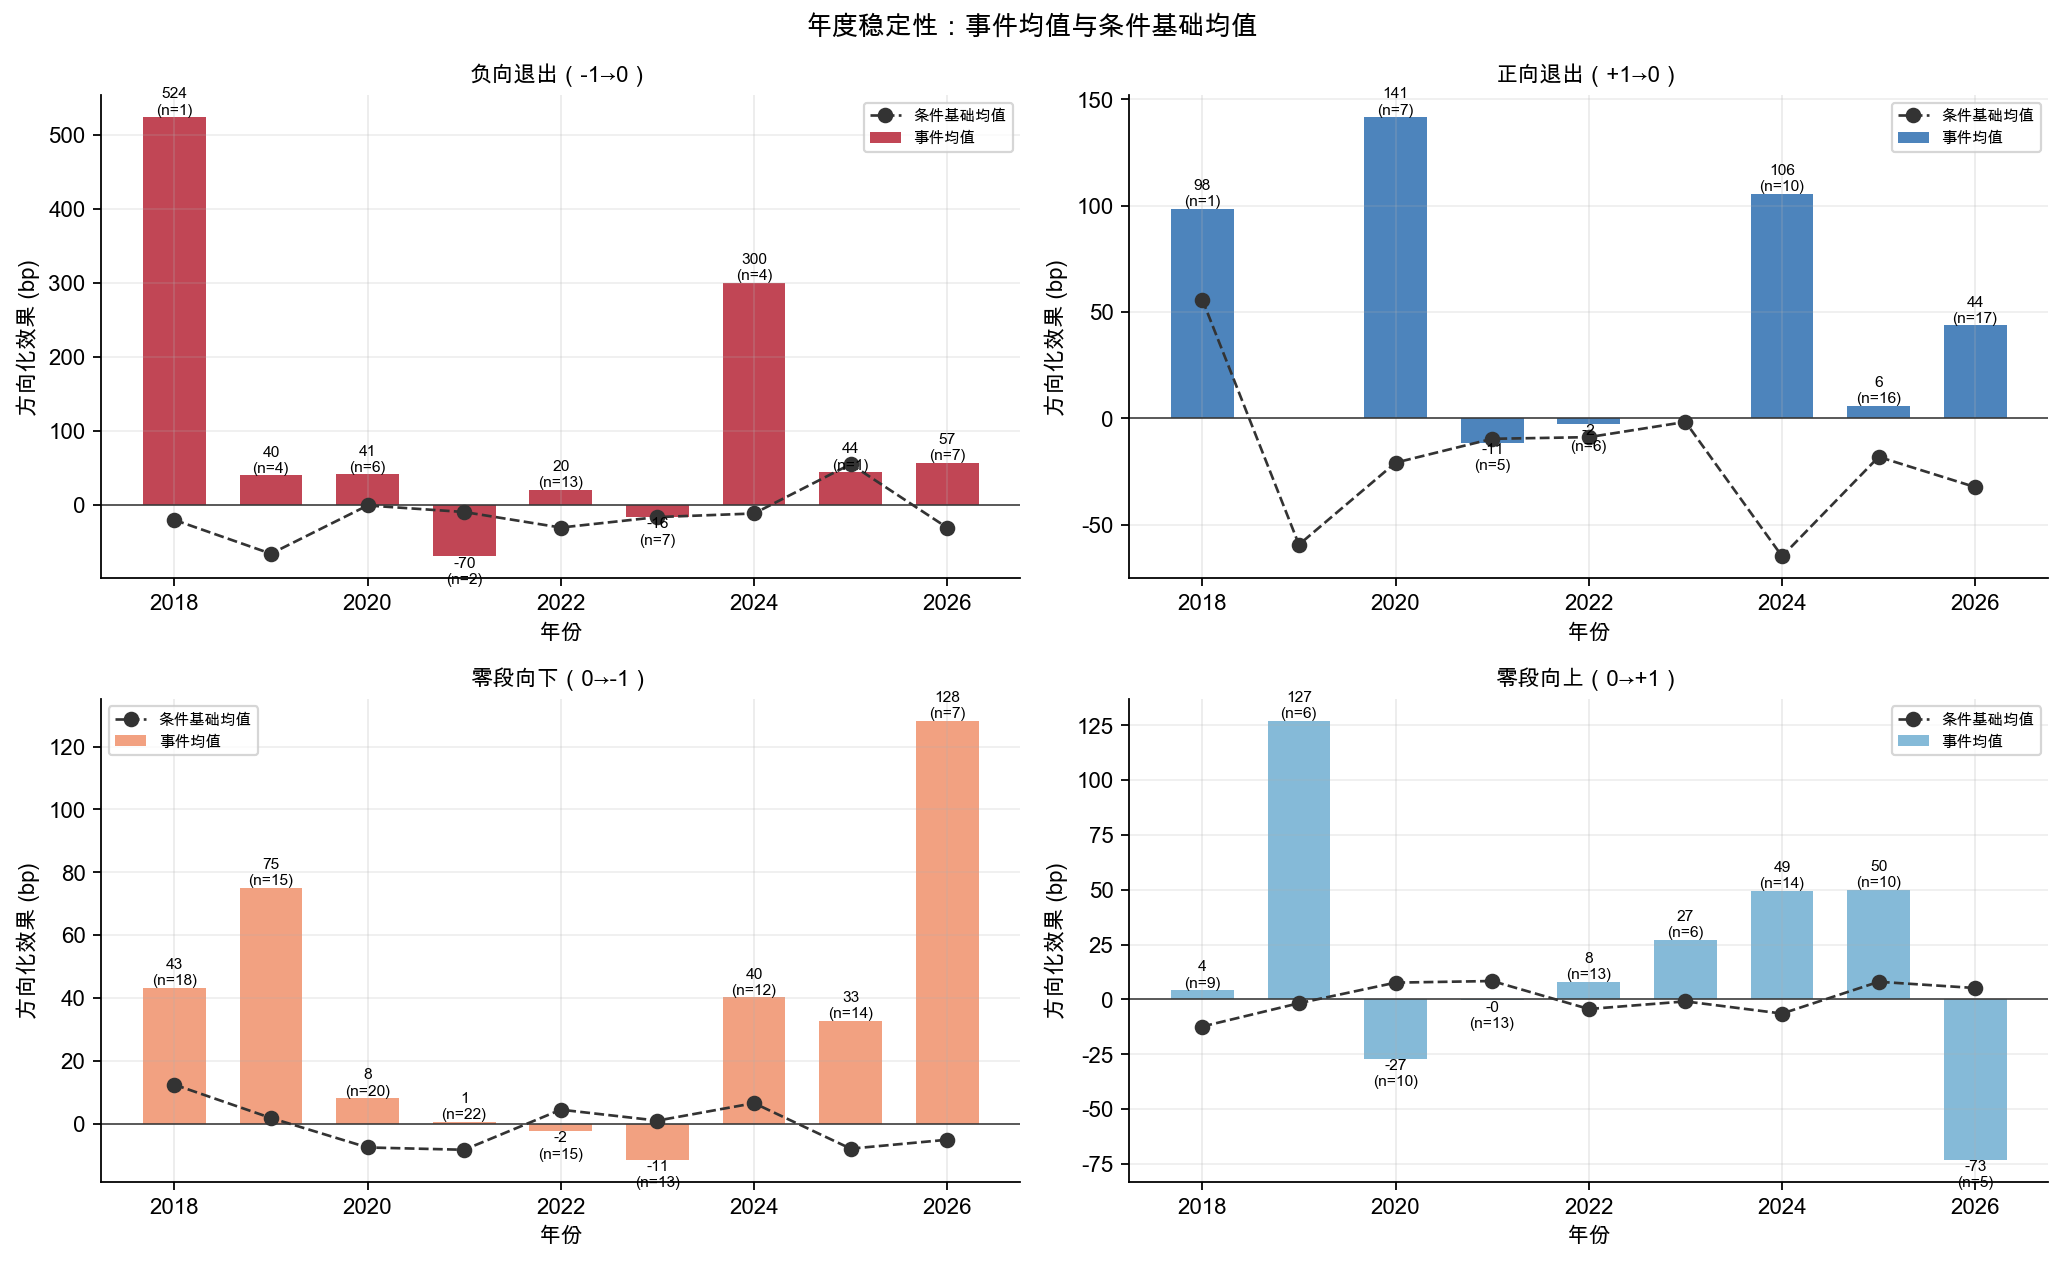

In [8]:
display(Image(filename=str(ROOT / results['figures']['annual'])))


### 四信号全局路径

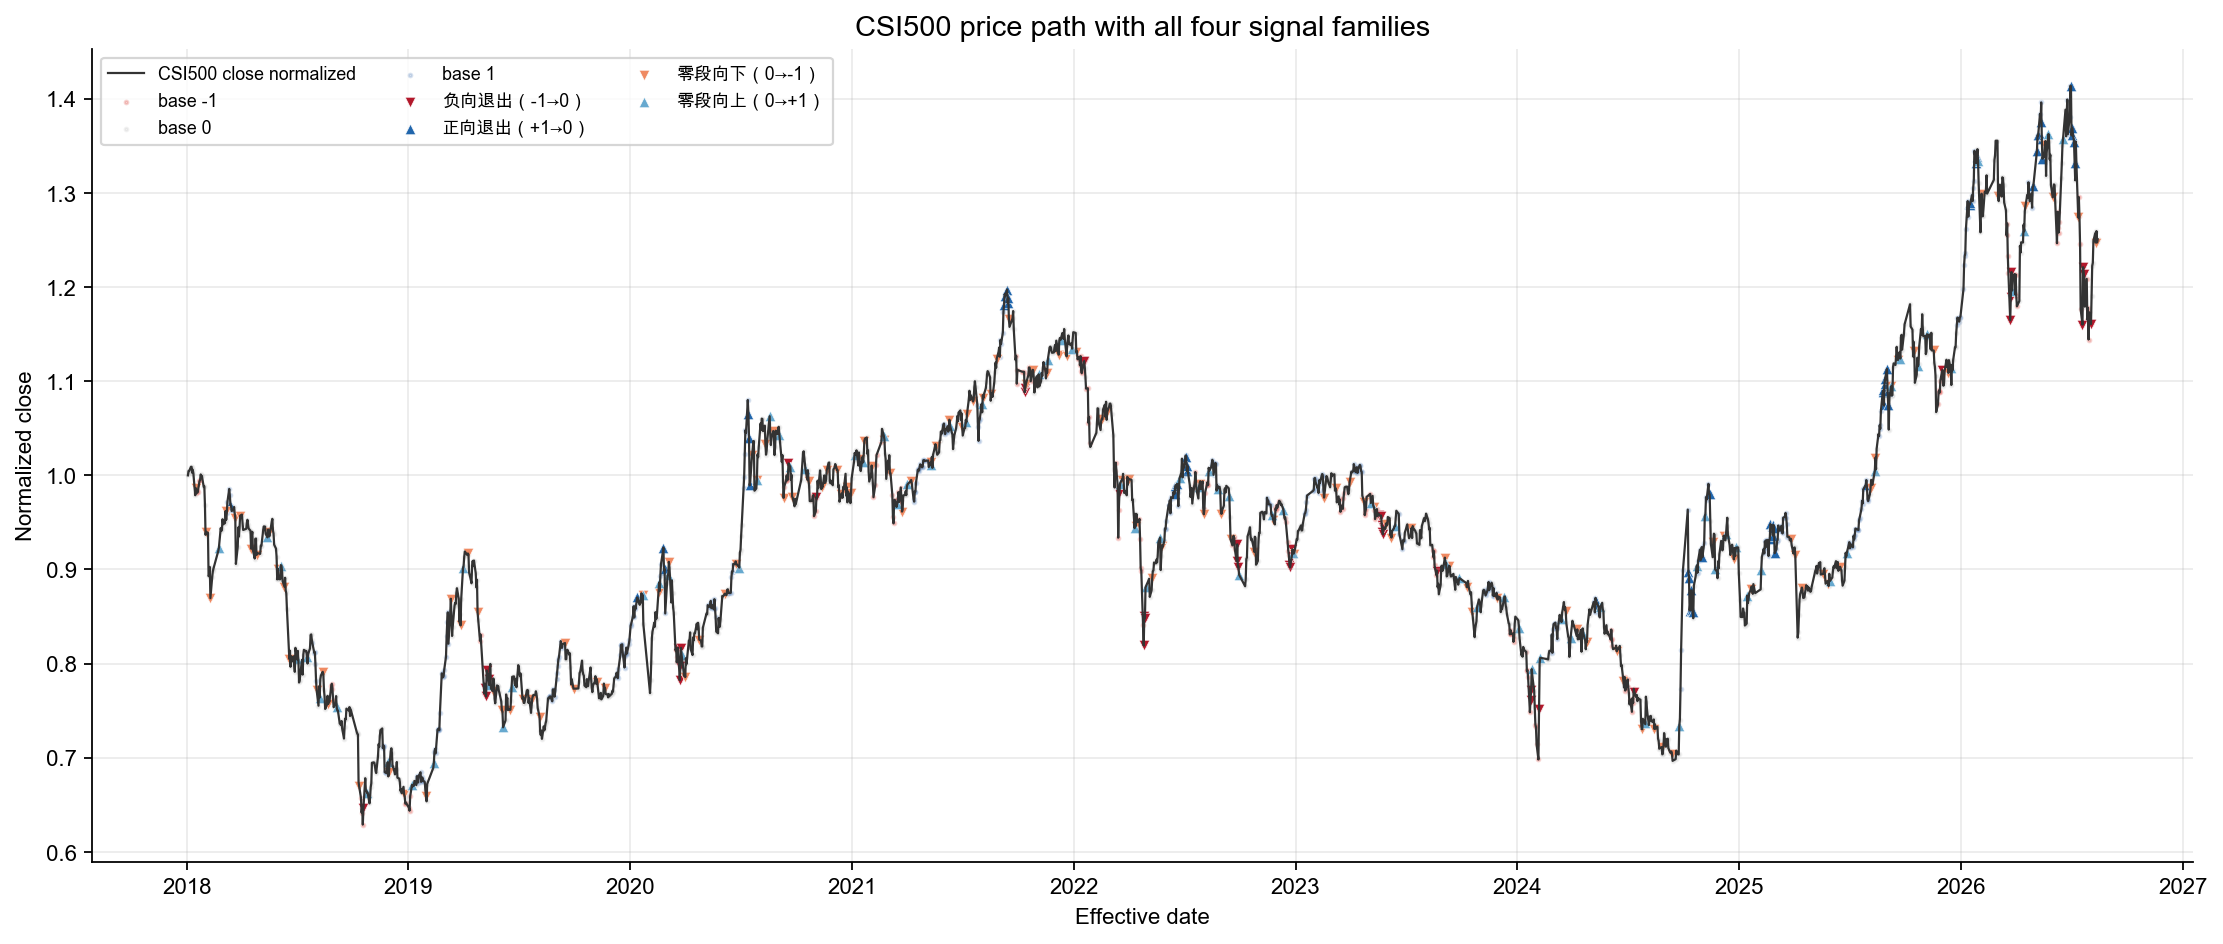

### 四信号效果比较

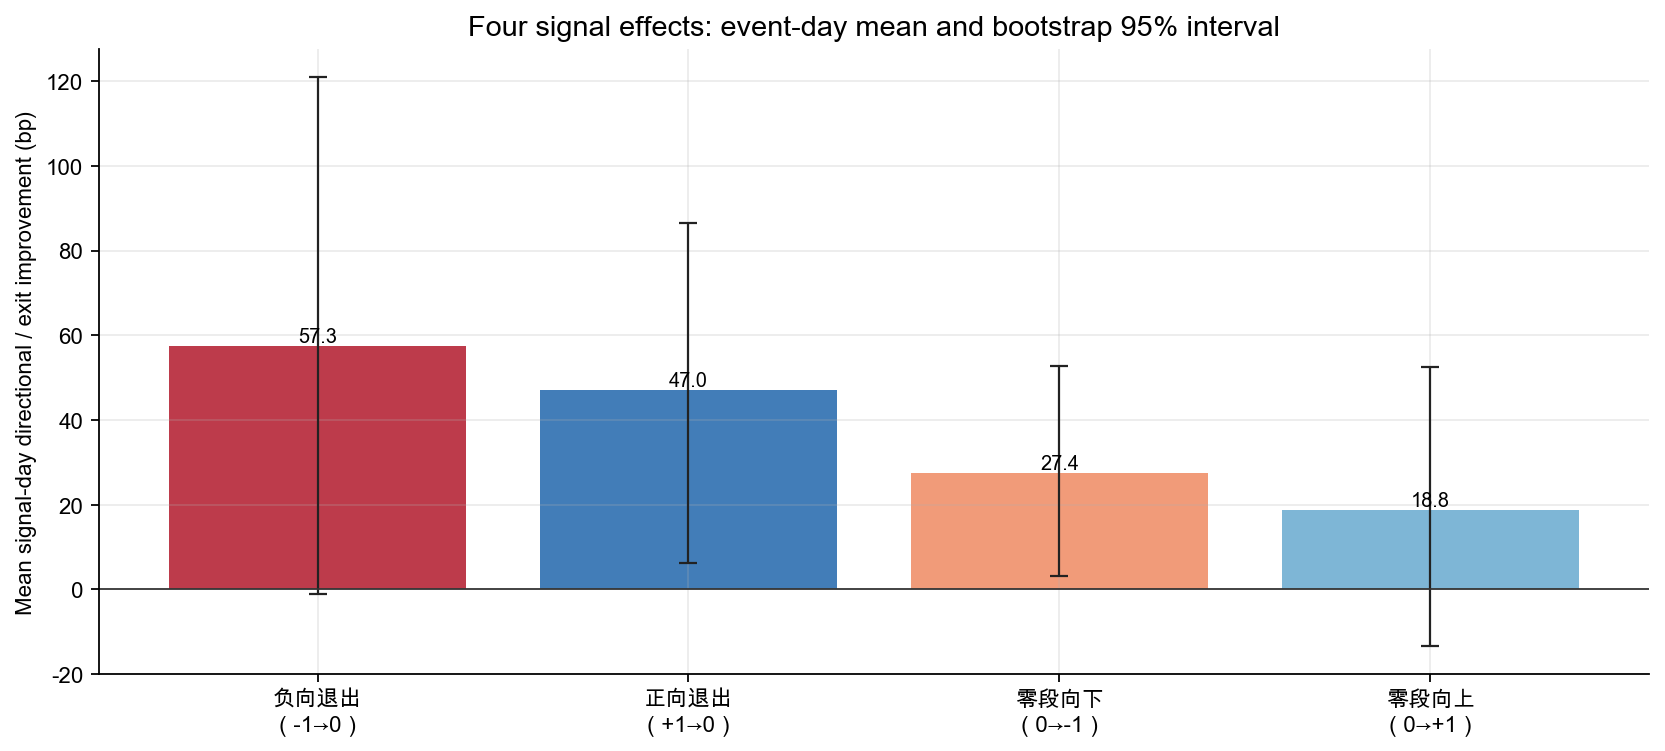

### 状态构成、段长和收益分布

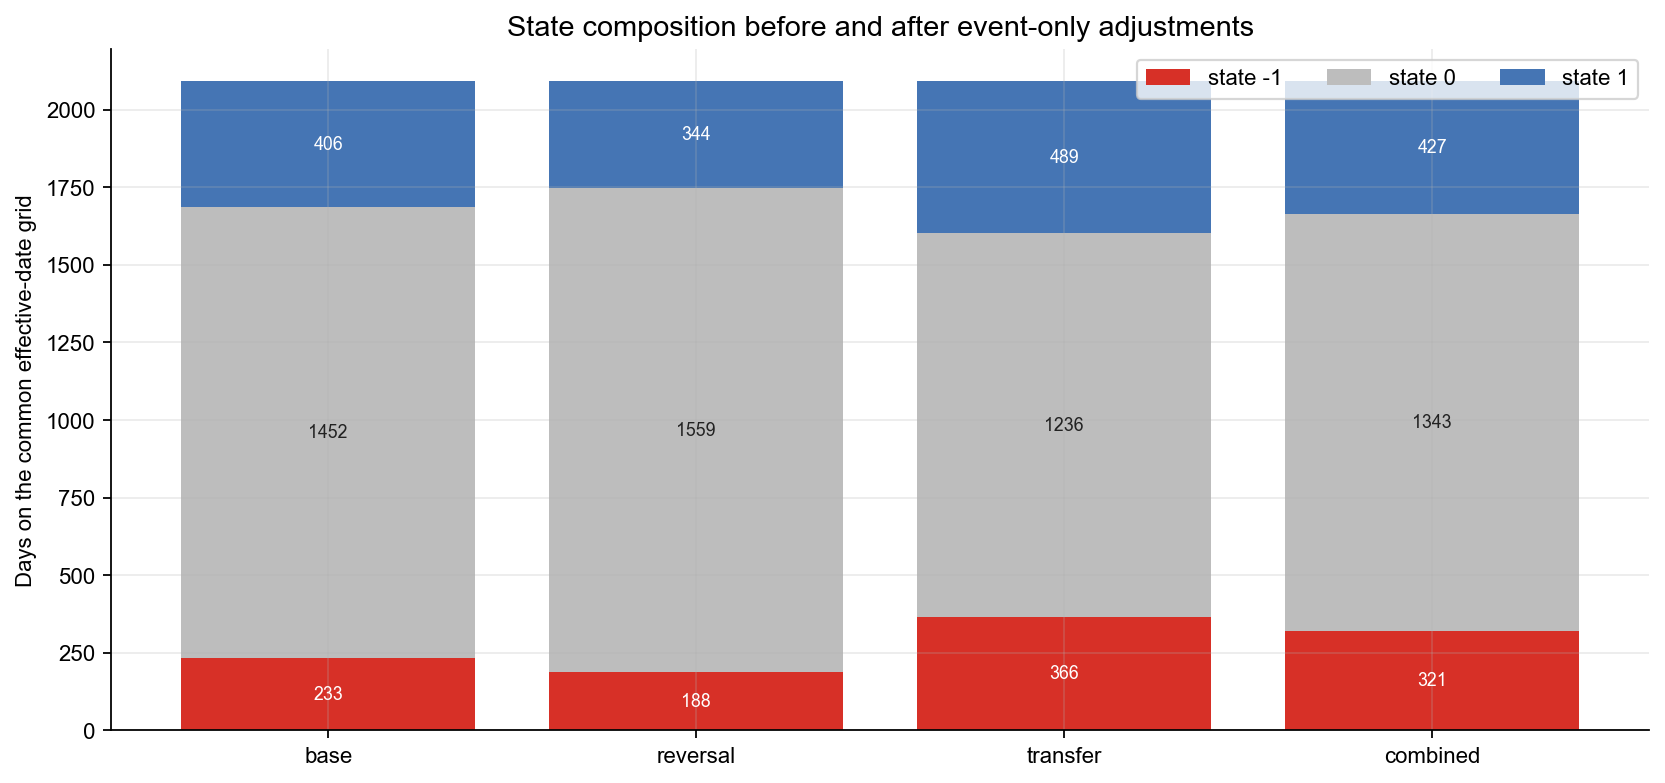

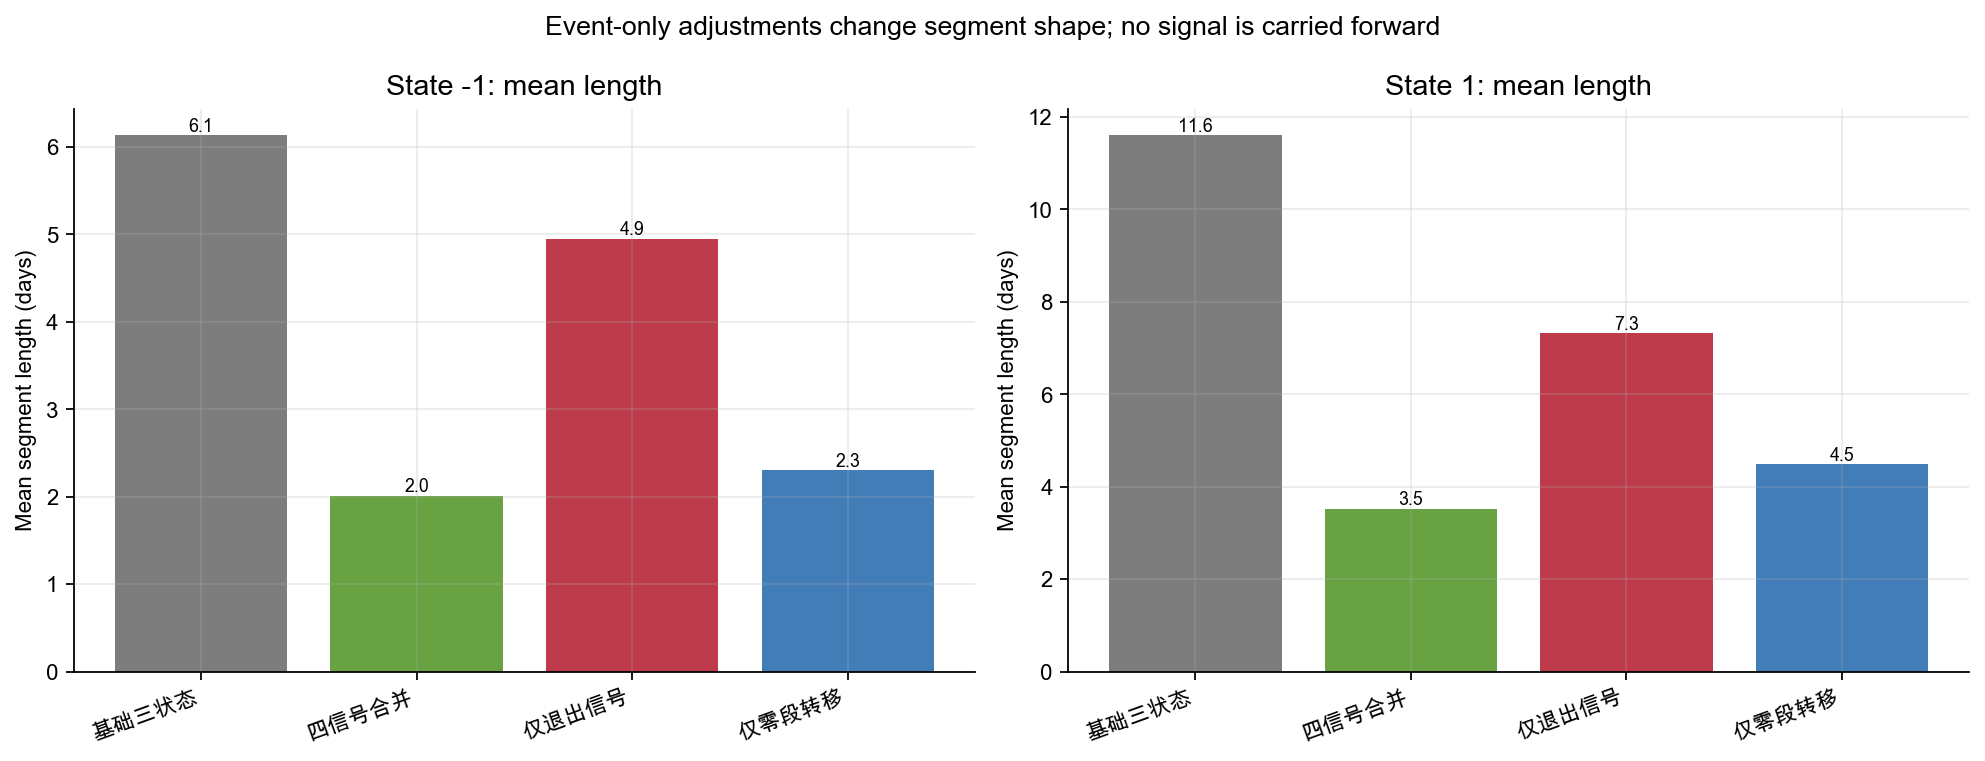

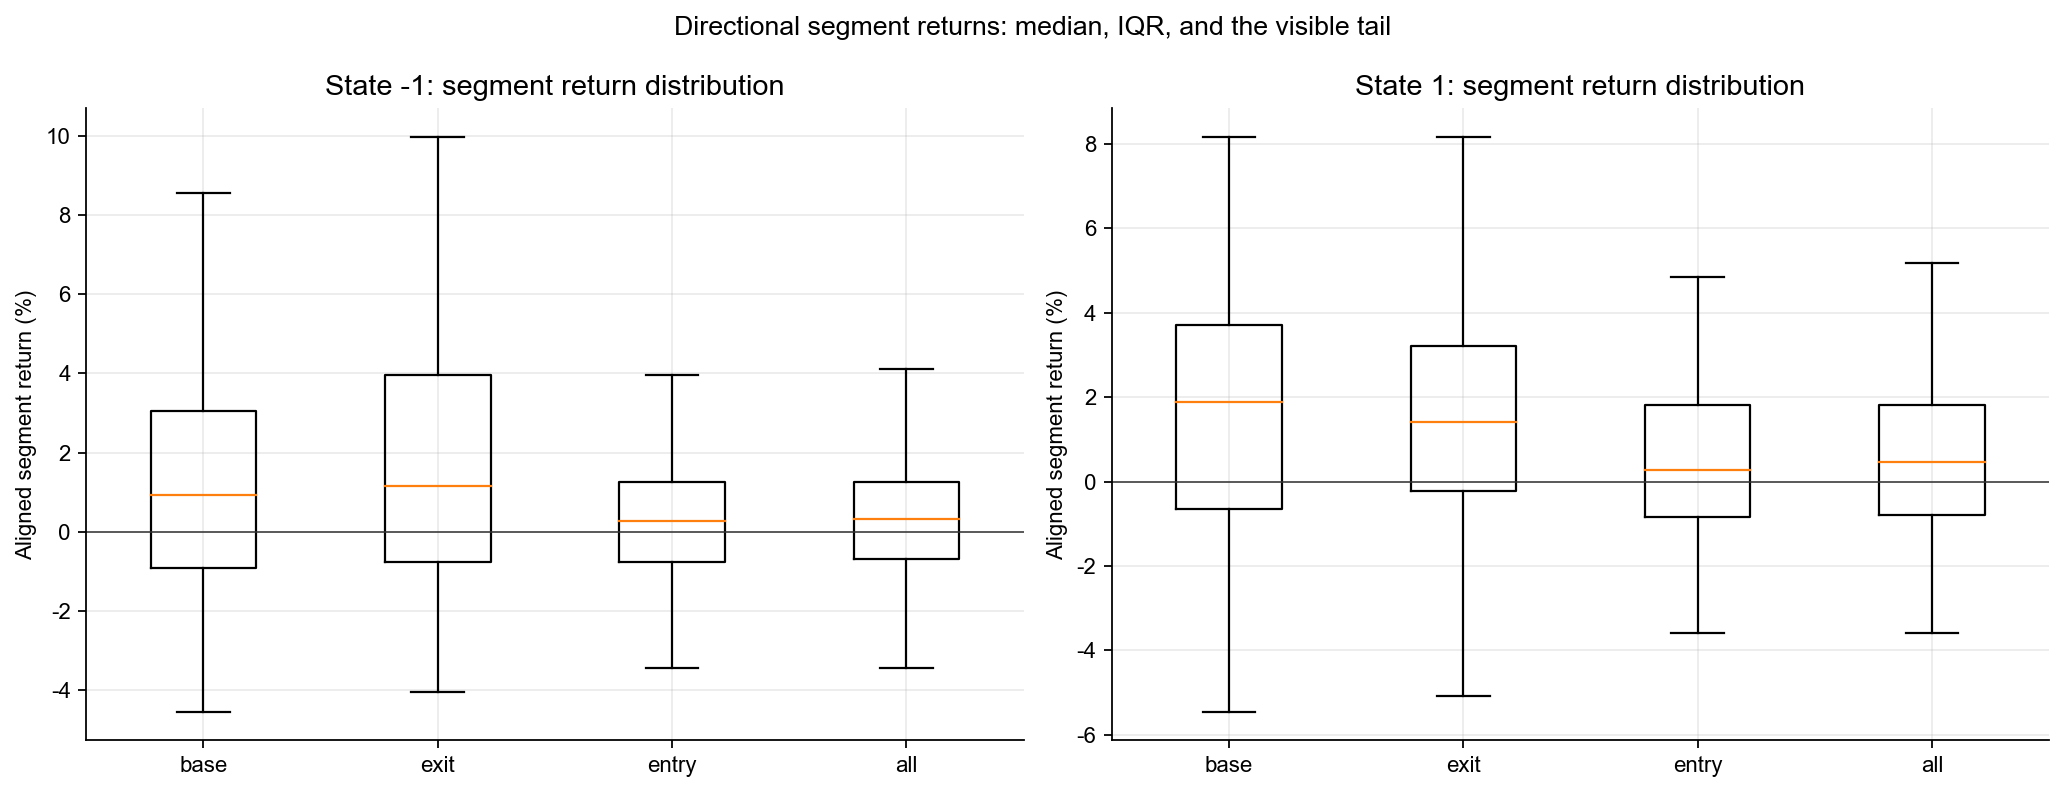

### 原始段反转和信号捕获

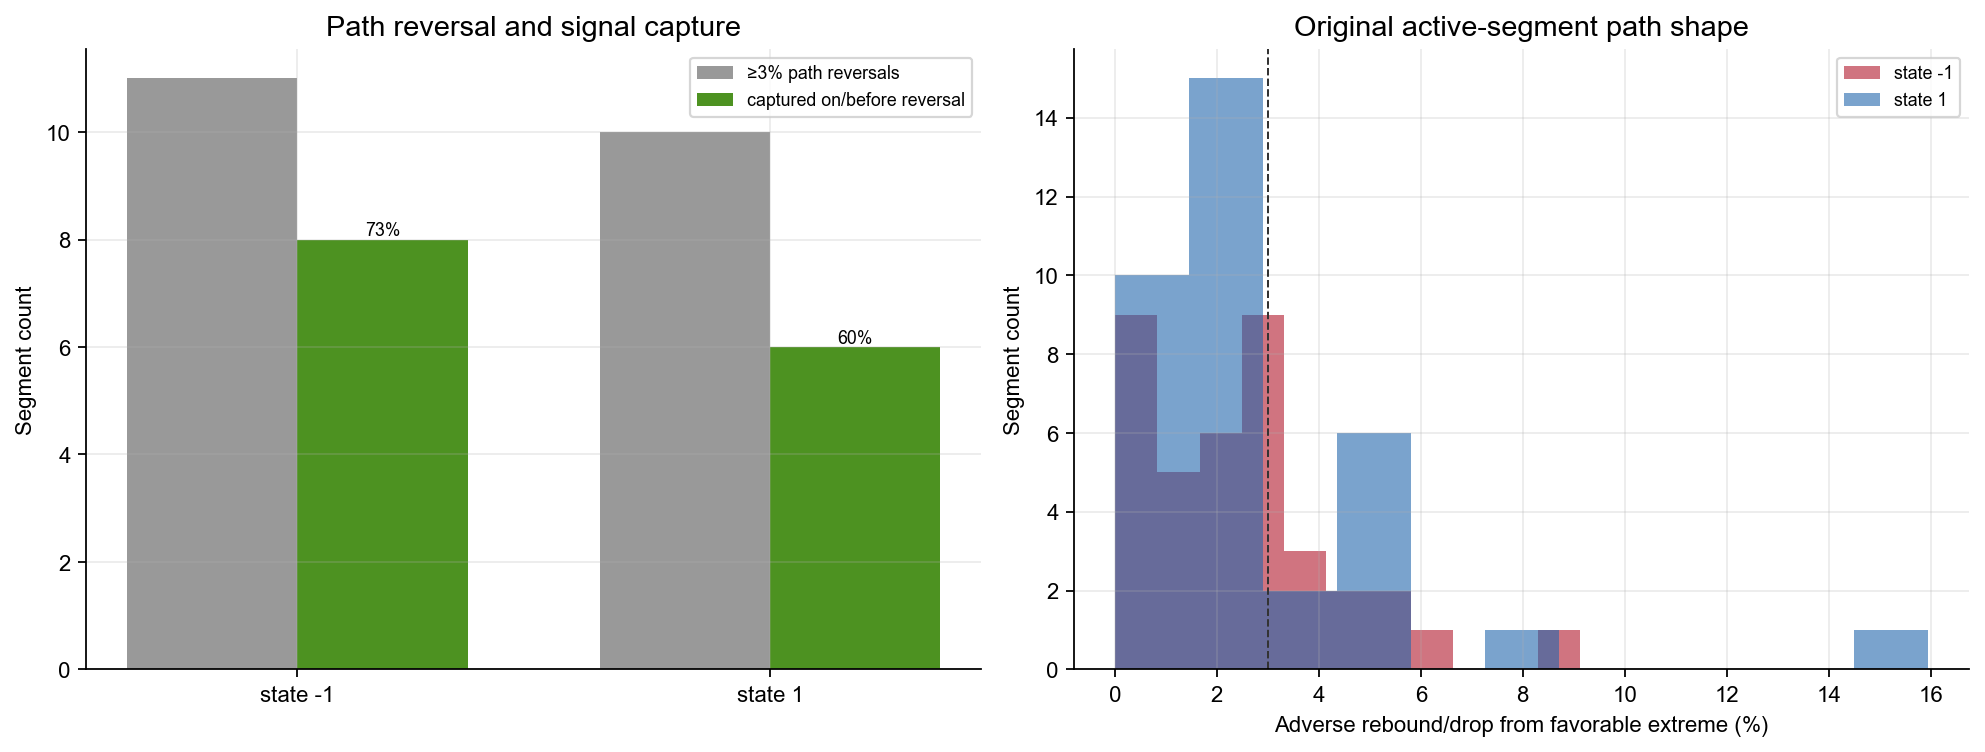

In [9]:
display(Markdown('### 四信号全局路径'))
display(Image(filename=str(ROOT / results['figures']['index_curve'])))
display(Markdown('### 四信号效果比较'))
display(Image(filename=str(ROOT / results['figures']['effect'])))
display(Markdown('### 状态构成、段长和收益分布'))
display(Image(filename=str(ROOT / results['figures']['counts'])))
display(Image(filename=str(ROOT / results['figures']['duration'])))
display(Image(filename=str(ROOT / results['figures']['returns'])))
display(Markdown('### 原始段反转和信号捕获'))
display(Image(filename=str(ROOT / results['figures']['shape'])))

minus_exit


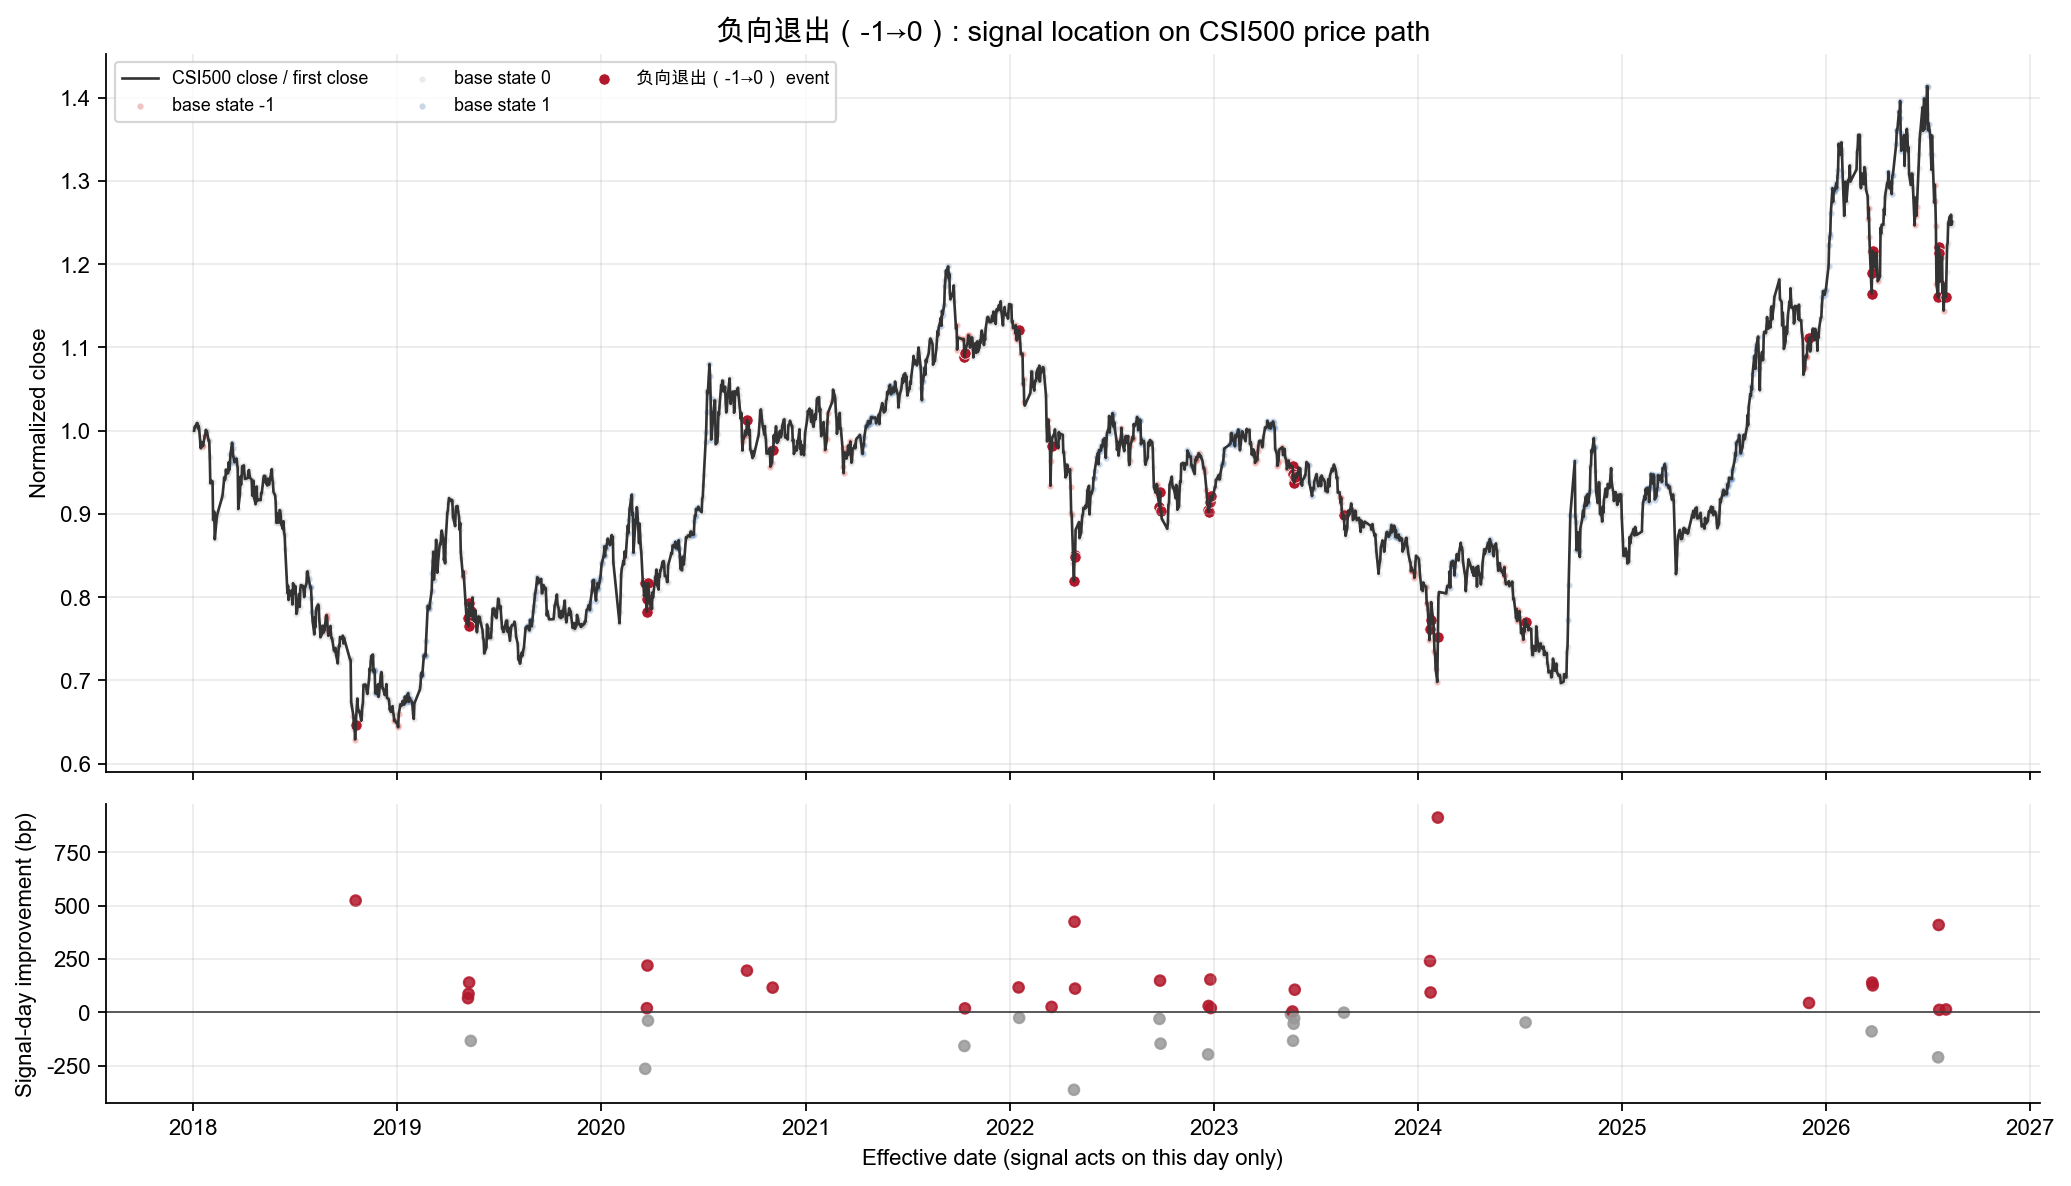

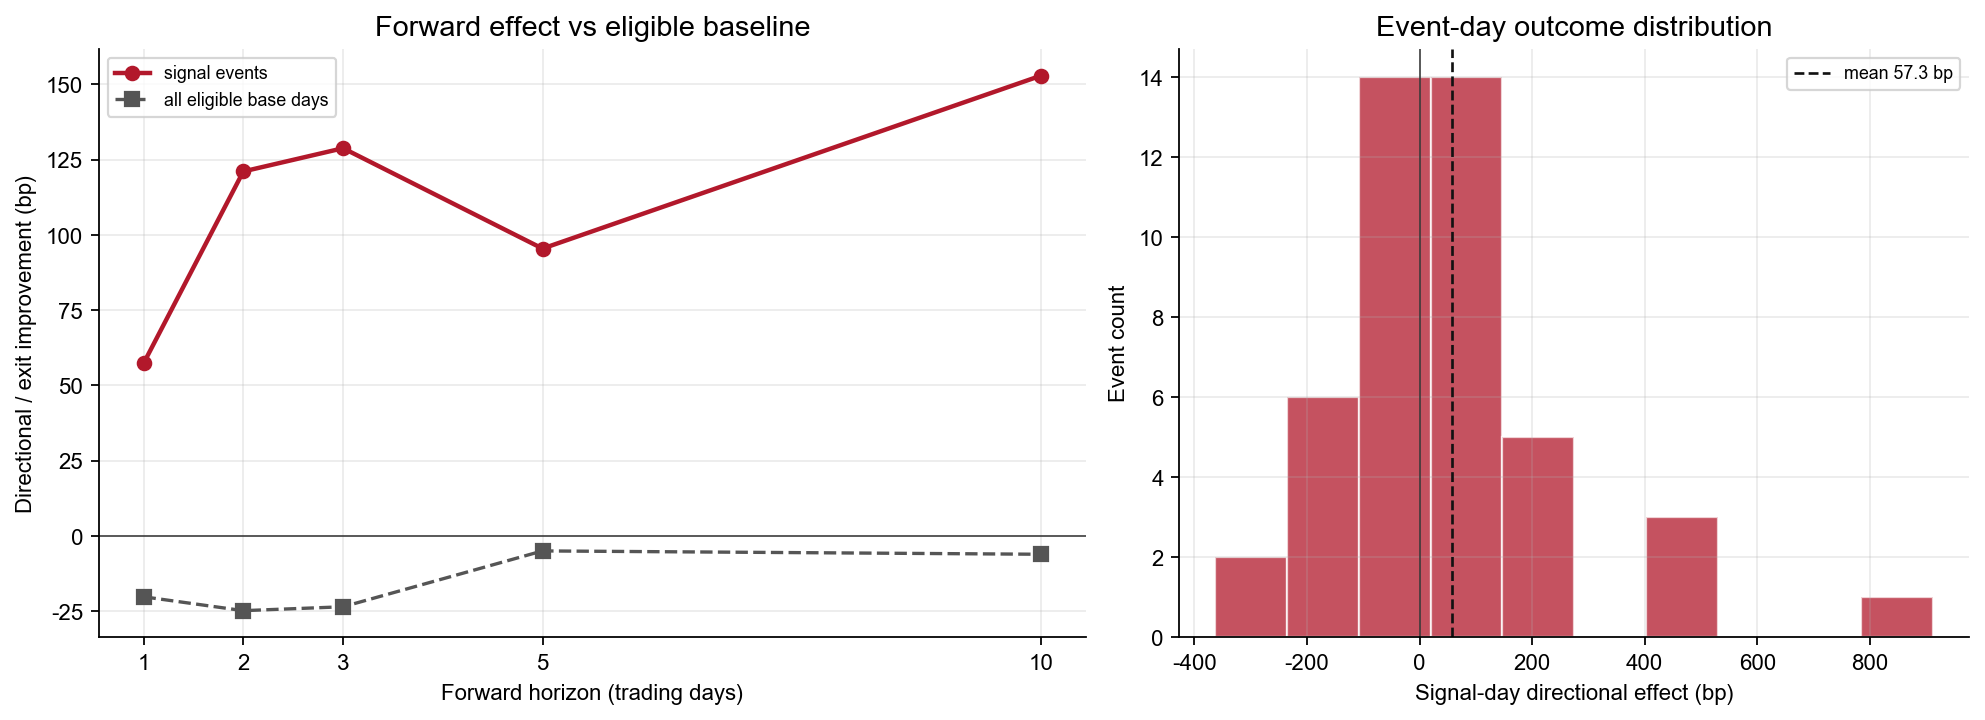

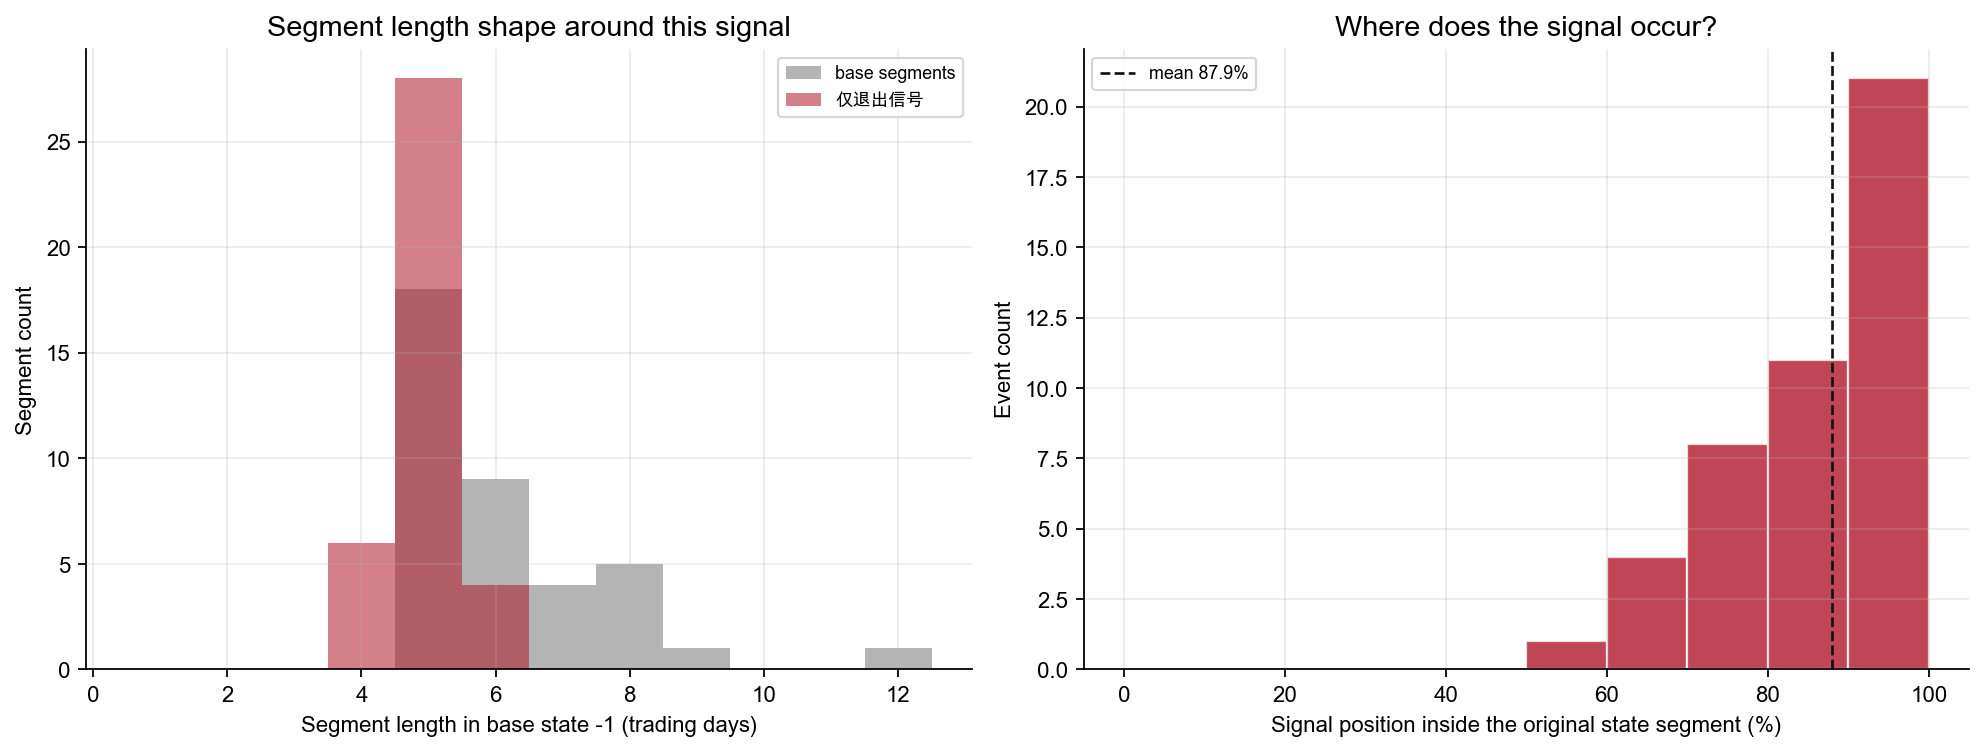

plus_exit


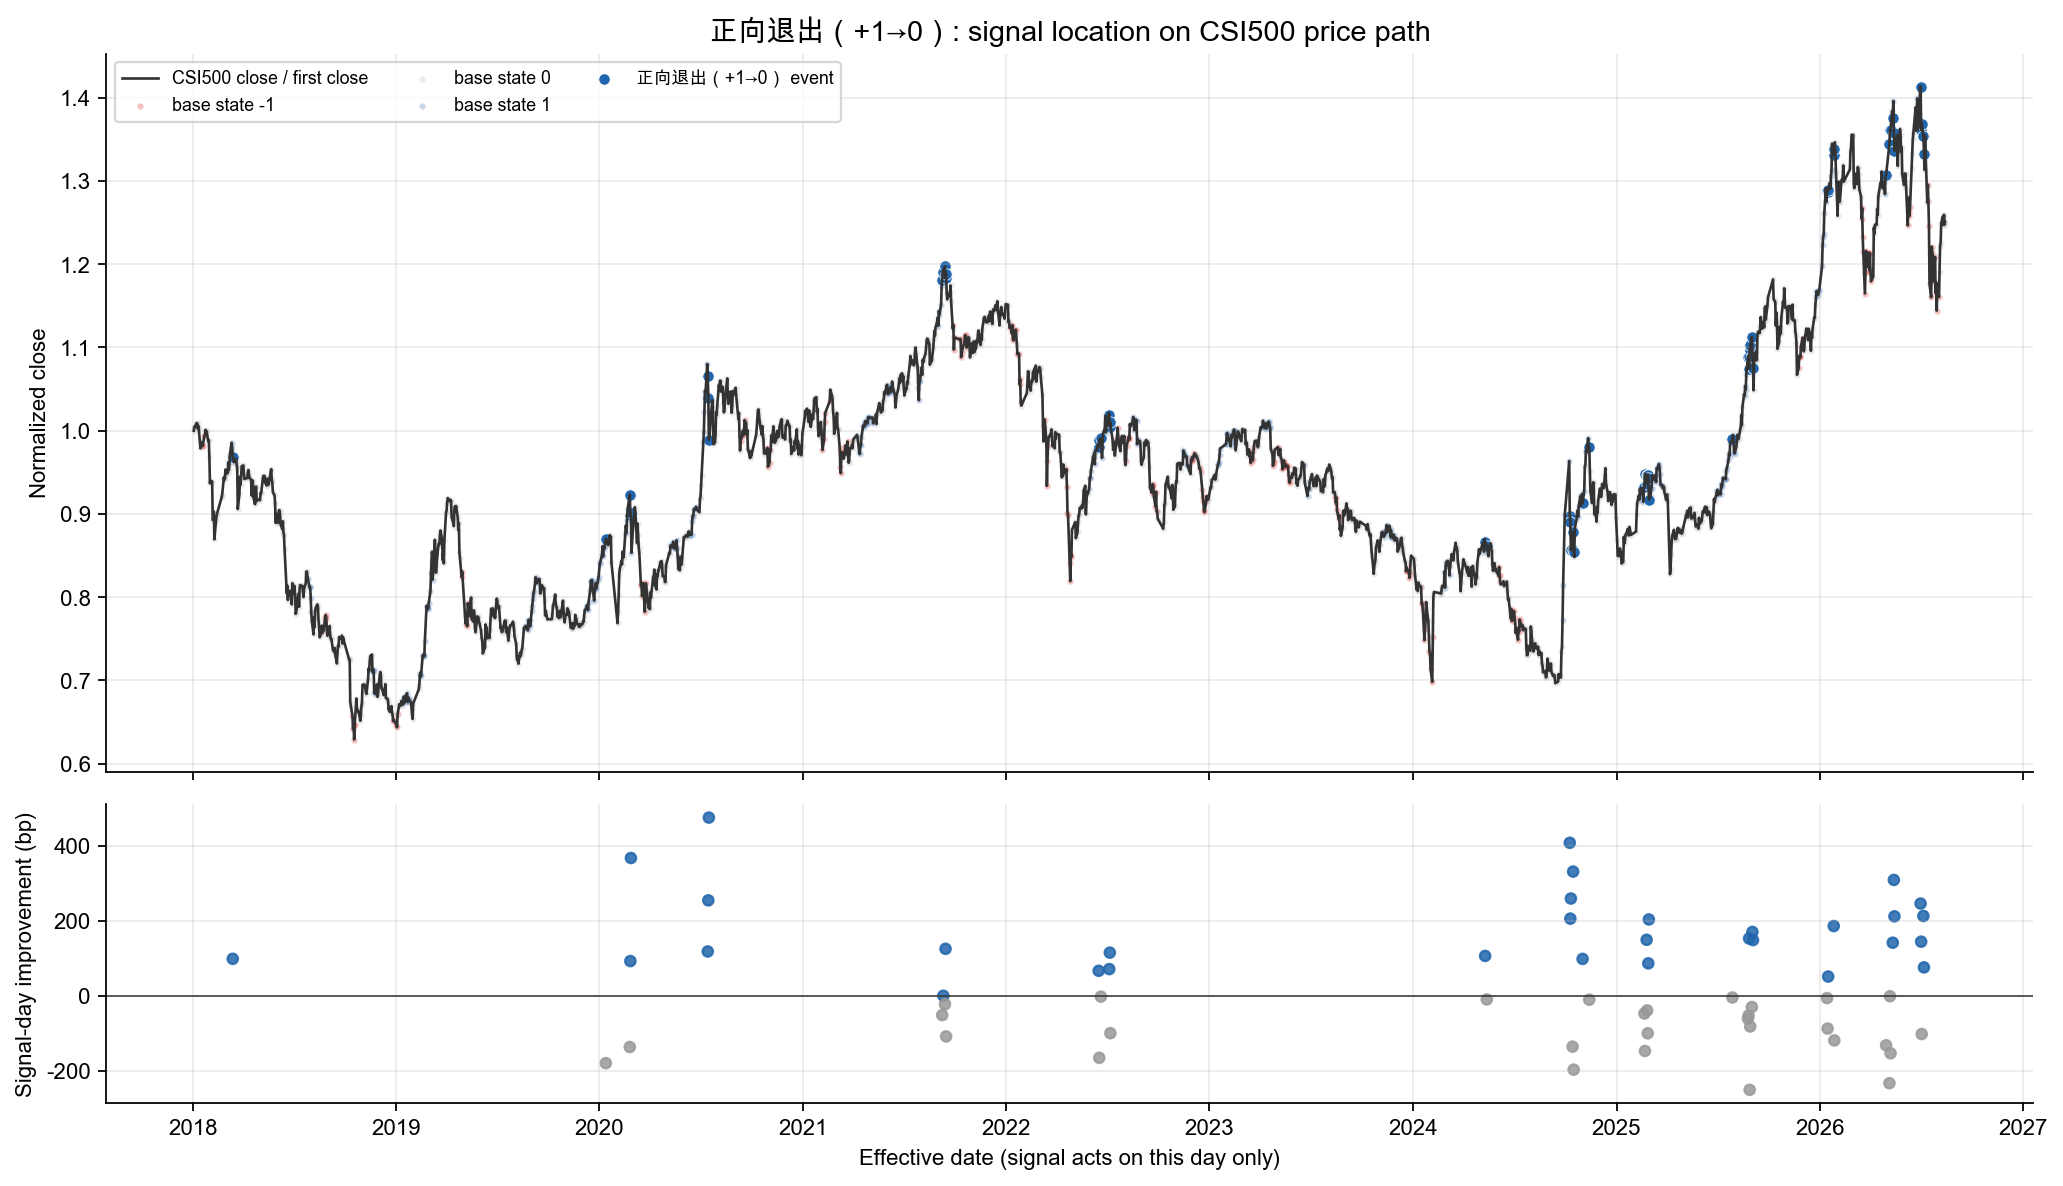

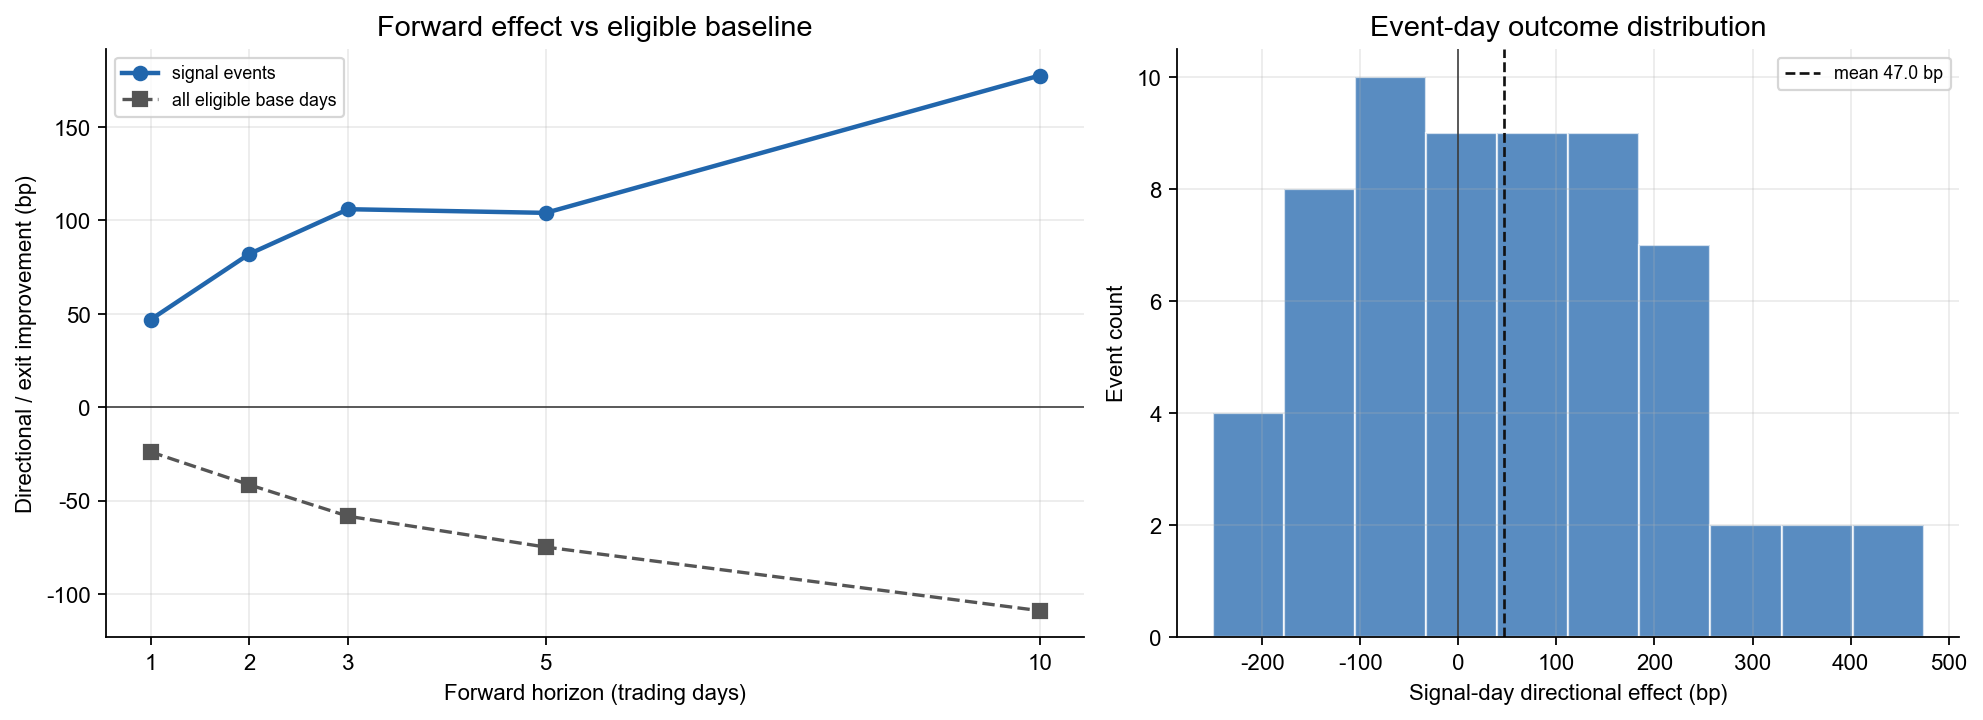

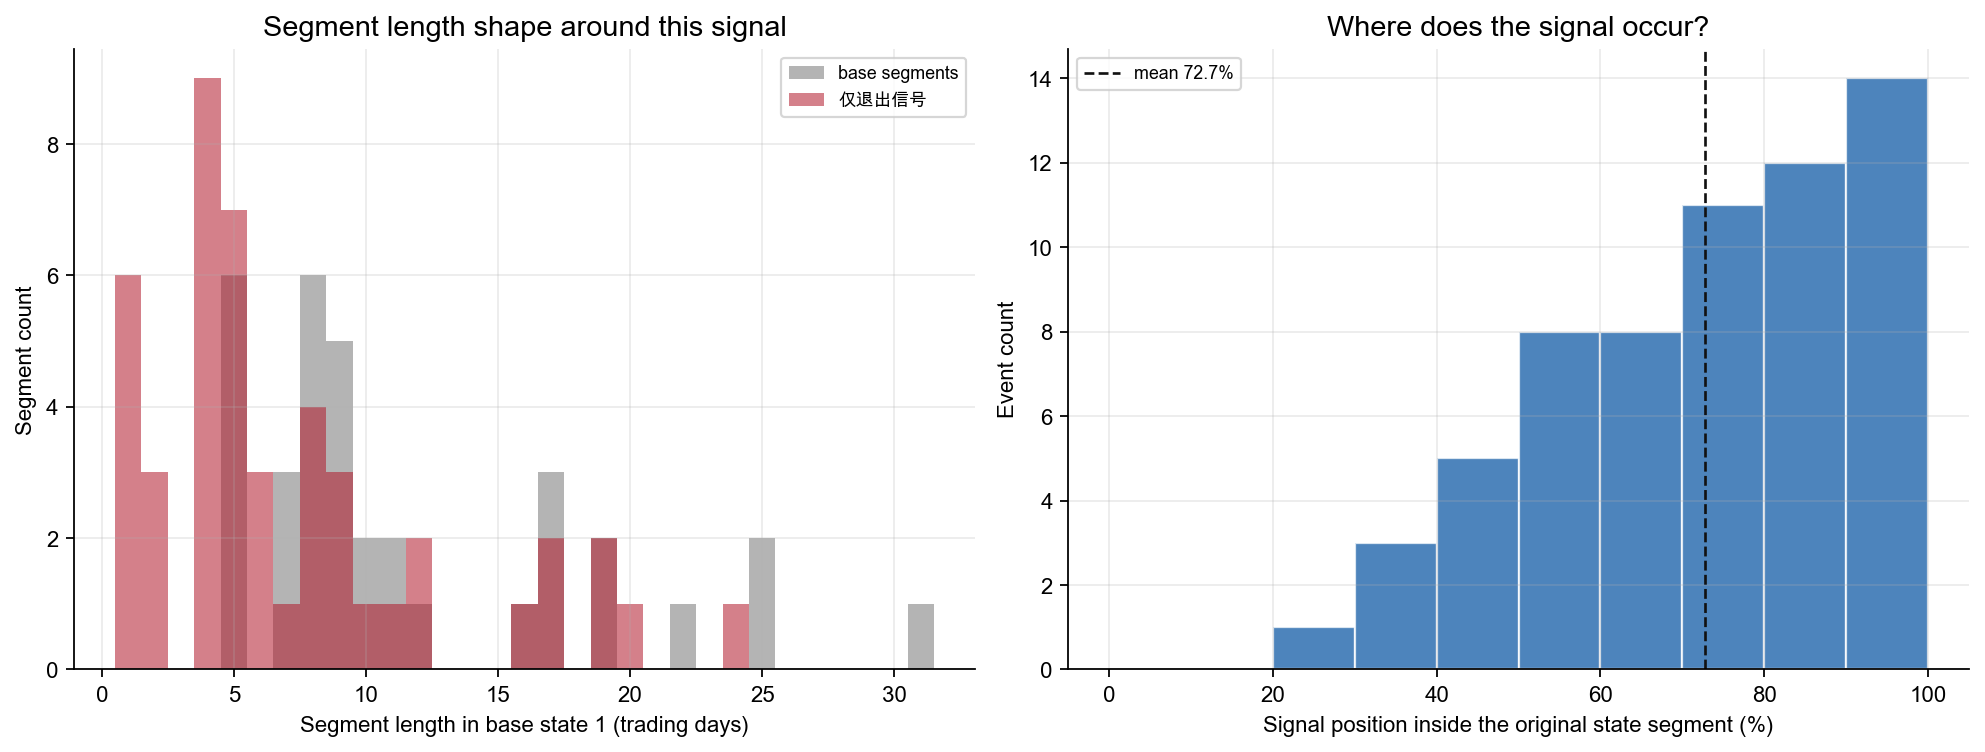

minus_entry


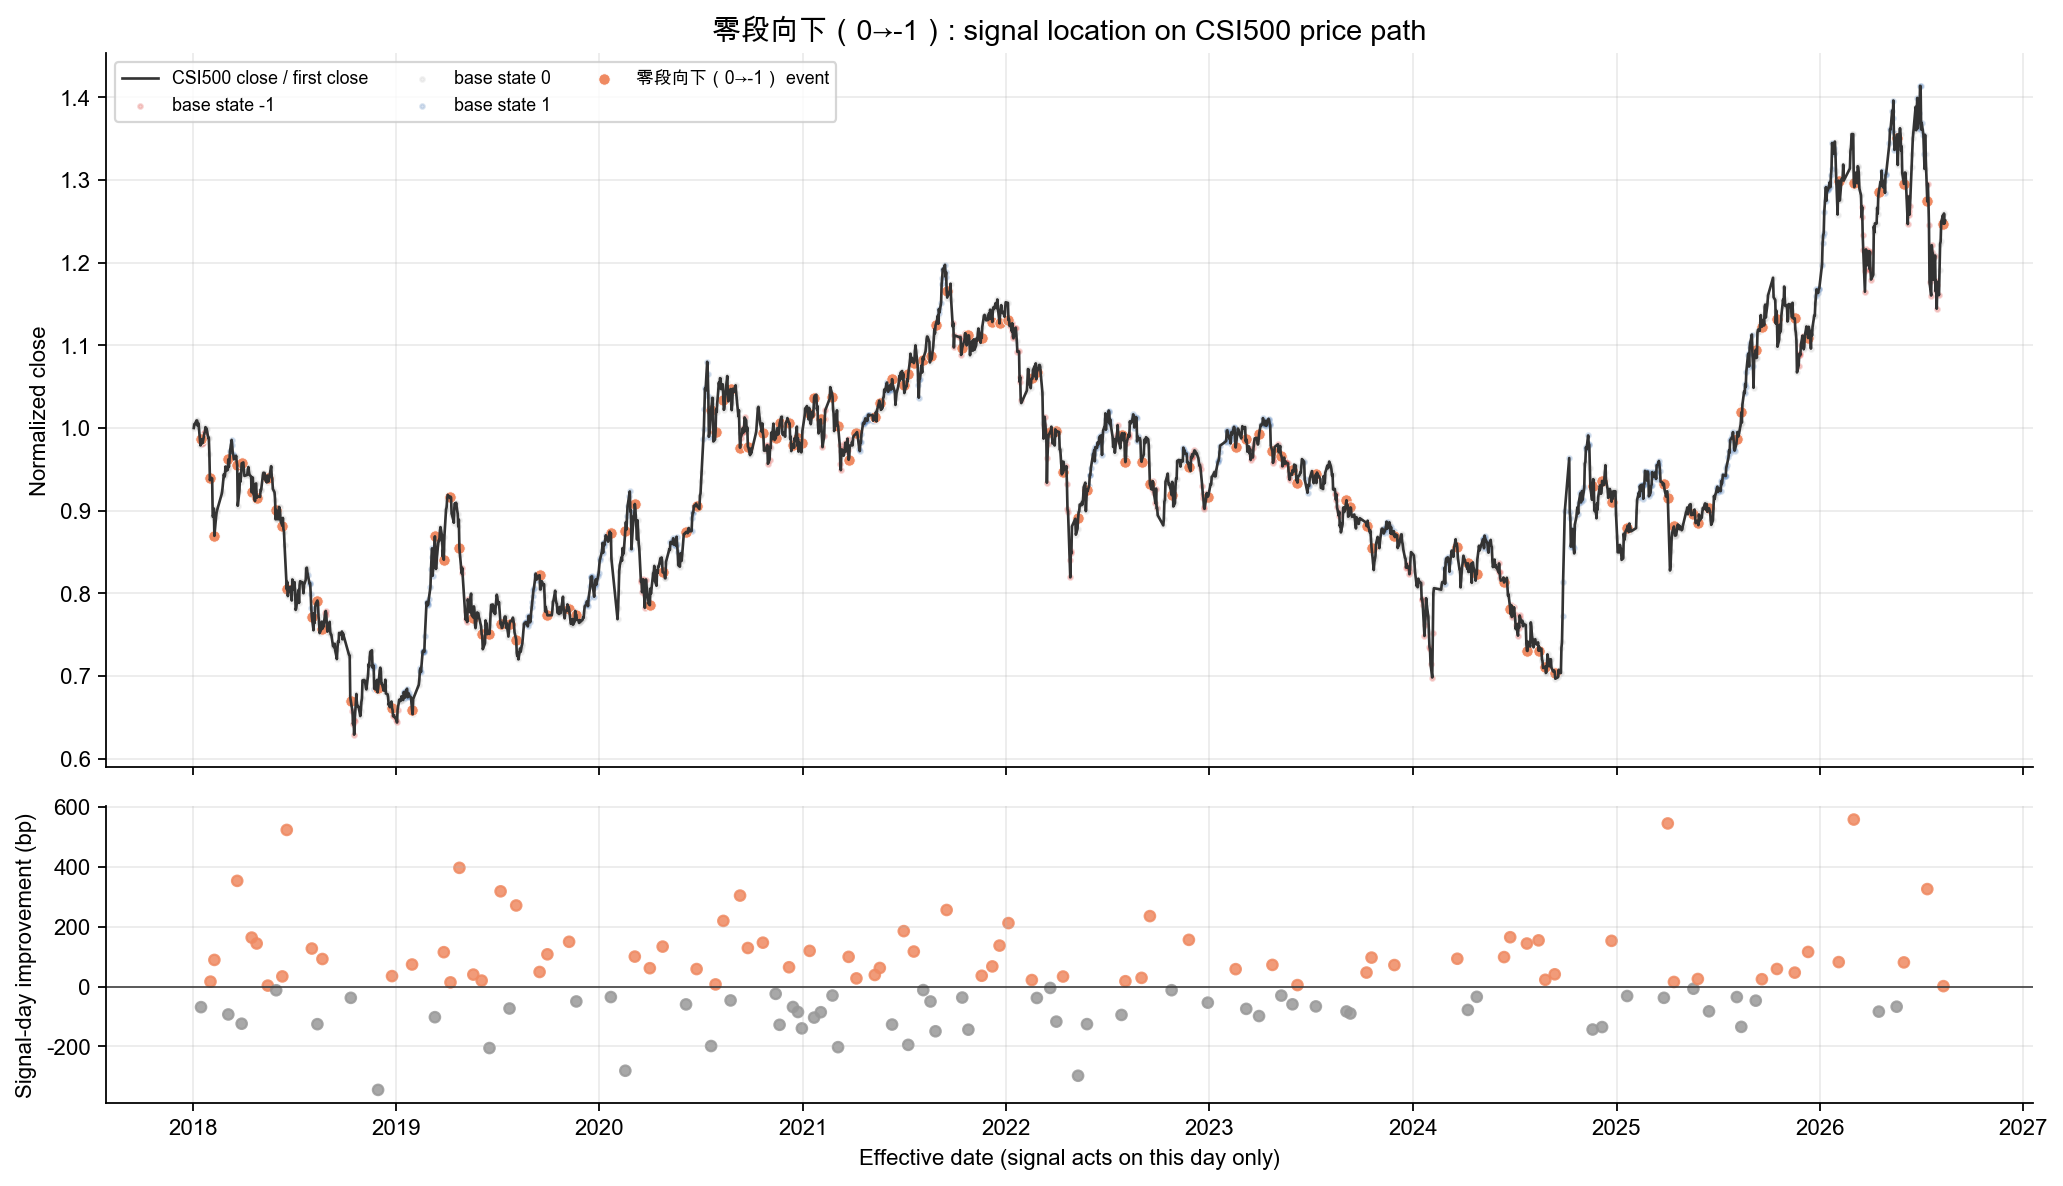

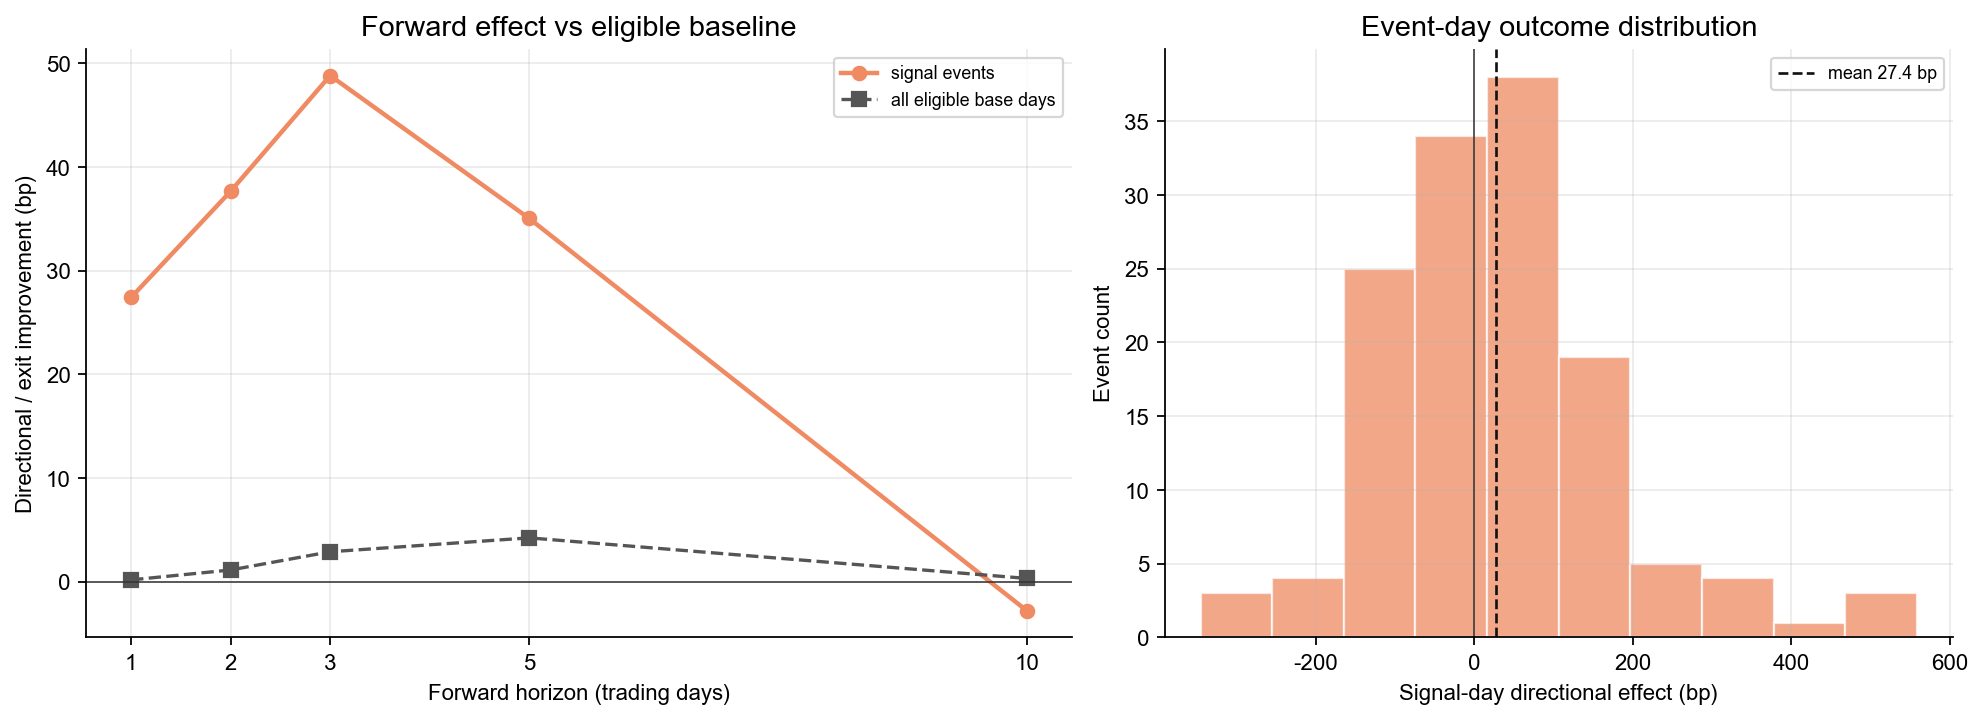

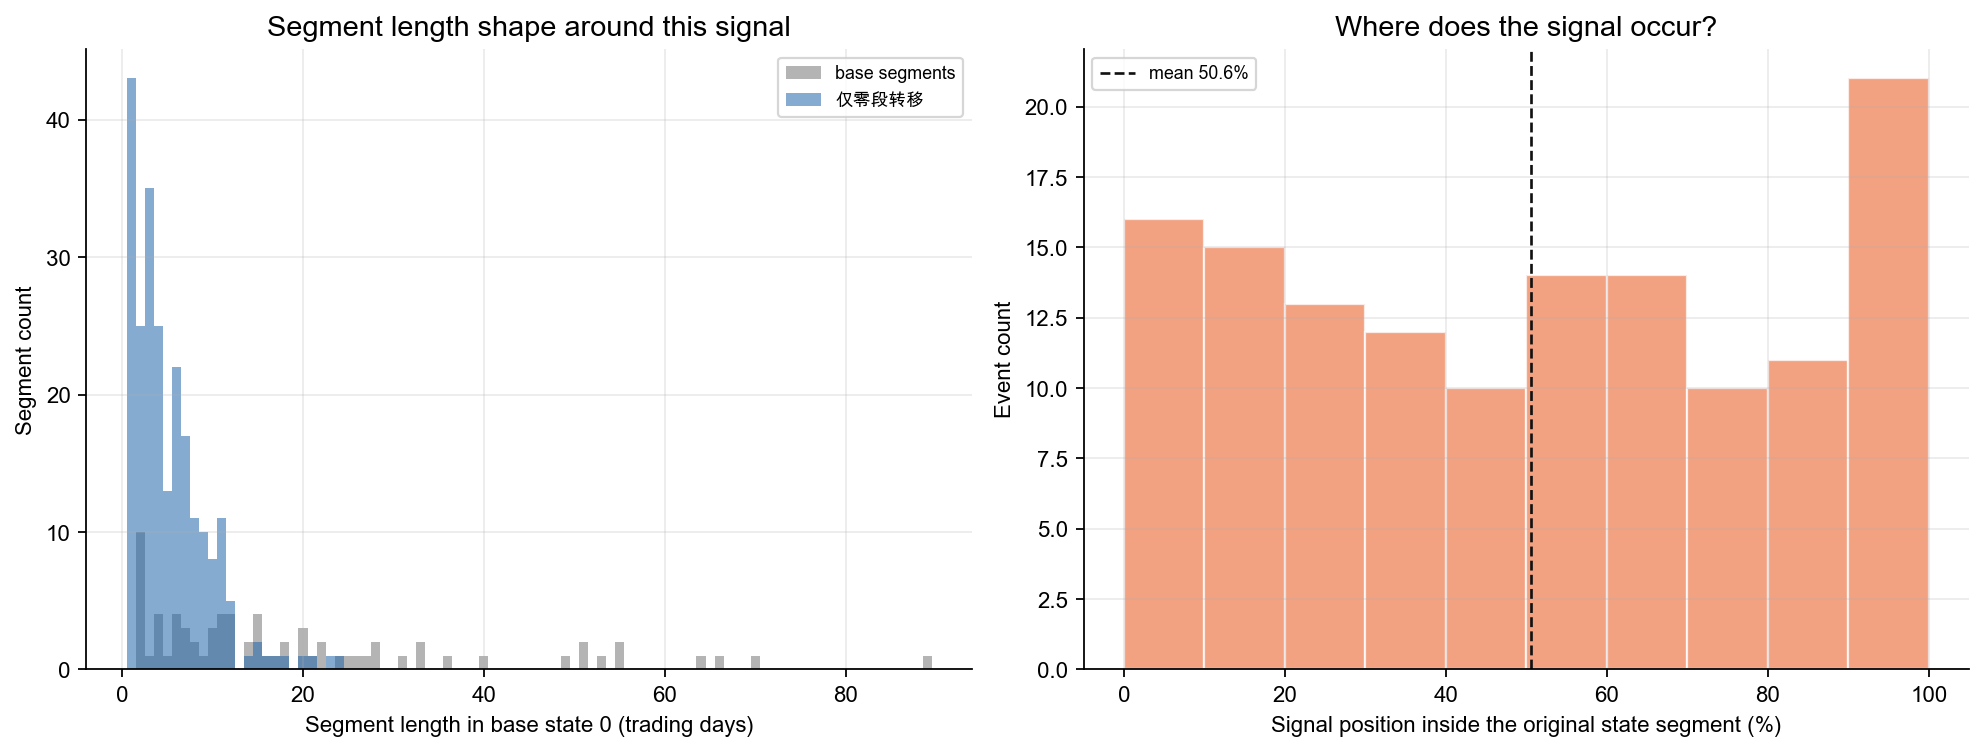

plus_entry


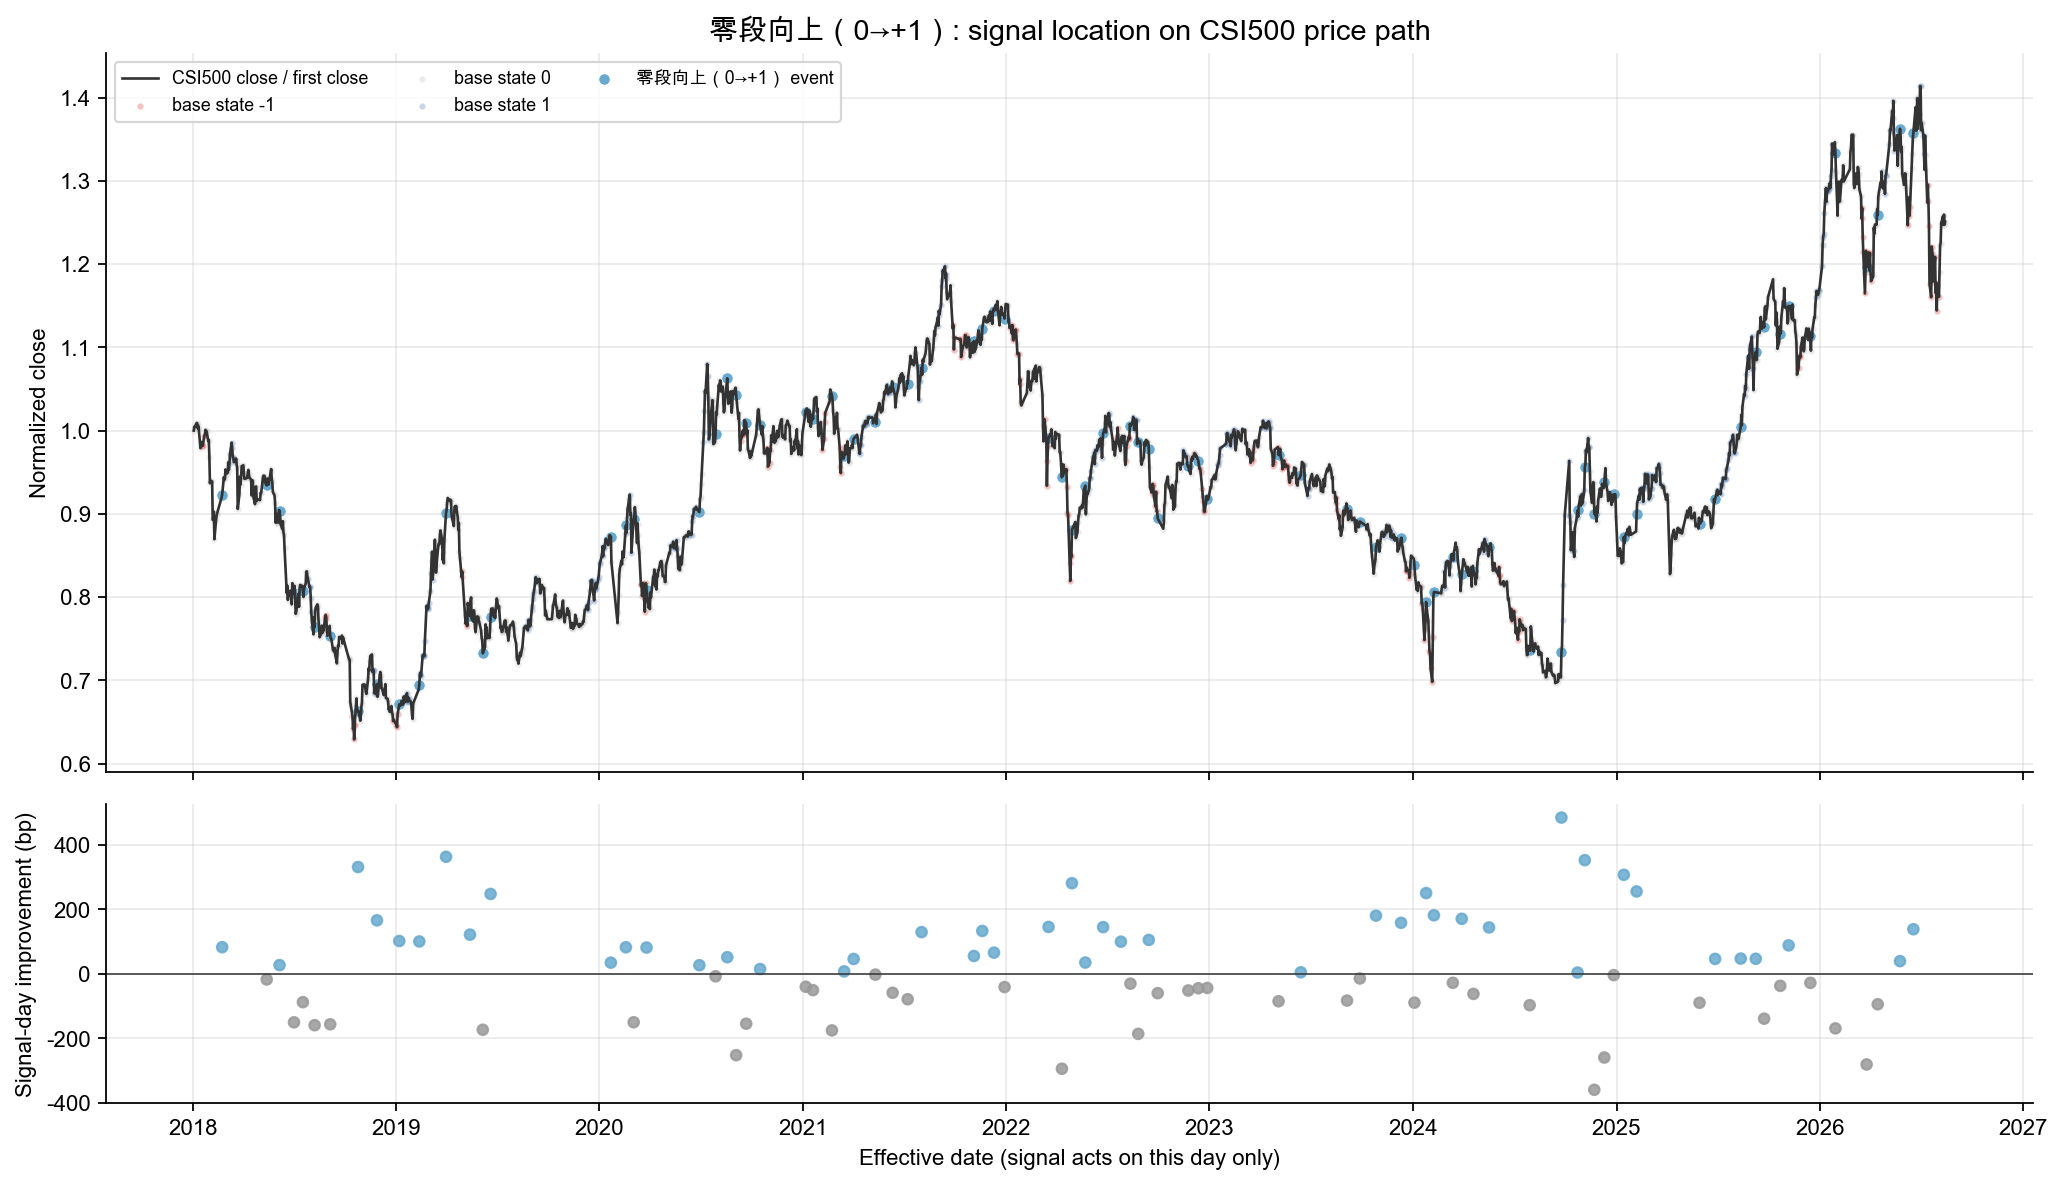

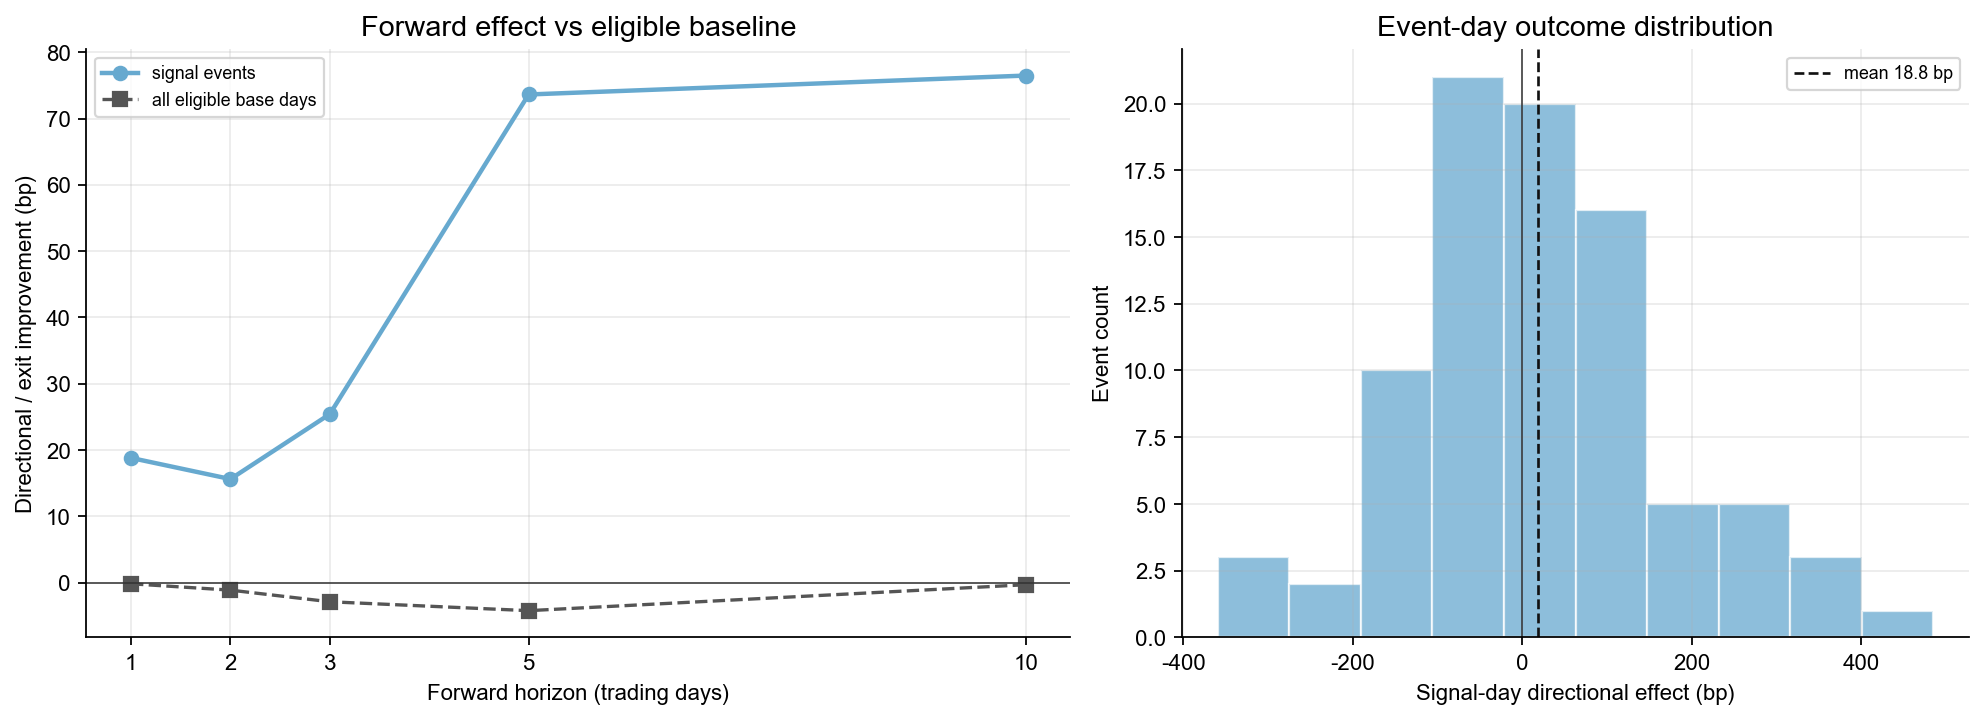

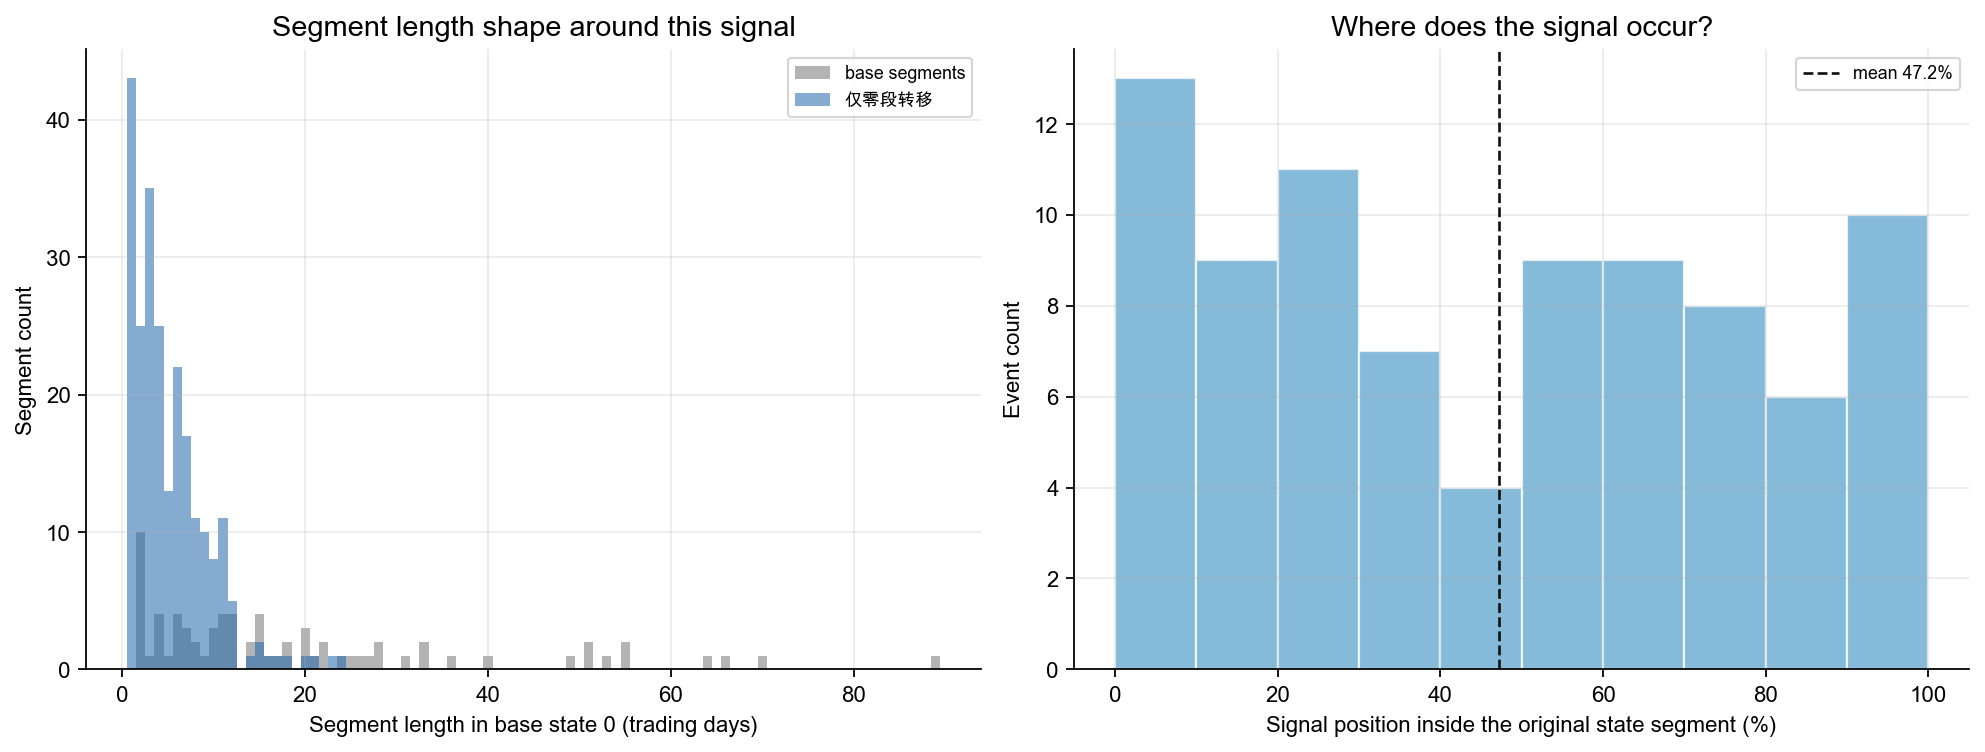

In [10]:
for key in ['minus_exit', 'plus_exit', 'minus_entry', 'plus_entry']:
    print(key)
    display(Image(filename=str(ROOT / results['figures'][f'{key}_timeline'])))
    display(Image(filename=str(ROOT / results['figures'][f'{key}_forward'])))
    display(Image(filename=str(ROOT / results['figures'][f'{key}_shape'])))

## 5. 文件交付

本次执行会更新：`01_报告资料与基础上传包/数据源/combined_four_signals_nine_columns.csv`、`01_报告资料与基础上传包/统计表/`、`03_汇报版本/20260817_1628_03汇报_基础合并版/图片/`、四个中文单信号 Markdown 和 `四个反转信号合并总体分析.md`。四个单信号报告彼此独立，均包含定义、分阶段数据、前向分布、原始段位置、段形状和图表。